# 04 - Avaliação Aprofundada do Modelo

Este notebook aprofunda a avaliação do modelo vencedor do `03_modelagem.ipynb`: o **Pipeline C' (Behavioral + 5 features cadastrais macro) com Random Forest**.

**Objetivo:** ir além das métricas agregadas do notebook anterior e responder às perguntas que uma área de crédito faria:
- Qual a performance real do modelo em curvas (ROC, PR, captura)?
- Quais features realmente importam, e em que direção?
- Qual o limiar de decisão ótimo dado o custo assimétrico dos erros?
- Qual o impacto de negócio: quantos inadimplentes conseguimos capturar sinalizando os X% mais arriscados?

**Restrição metodológica:** todas as previsões usadas aqui são **out-of-fold**, geradas com o mesmo split por grupo (`StratifiedGroupKFold`, `groups=grupo_cadastro`) do notebook 03. Isso evita o vazamento entre gêmeos e garante que as métricas sejam honestas.

**Convenções:** seguimos o `notebooks/README.md` (células numeradas, saídas salvas, parágrafo de interpretação abaixo de cada gráfico, `RANDOM_STATE=42`).

In [1]:
# =====================================================================
# 1.2 - Setup: imports, caminhos, configurações
# =====================================================================

import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from src.config import (
    RANDOM_STATE,
    TARGET,
    DATA_PROCESSED,
    CV_FOLDS,
    METRICS,
    FIGURES,
    MODELS,
)
from src.models import get_models
from src.evaluation import (
    ks_statistic,
    capture_at_k,
    plot_roc_curve,
    plot_pr_curve,
    plot_capture_curve,
)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10

pd.set_option("display.max_columns", None)

# Criar pastas de saída se não existirem
FIGURES.mkdir(parents=True, exist_ok=True)
METRICS.mkdir(parents=True, exist_ok=True)

print(f"RANDOM_STATE = {RANDOM_STATE}")
print(f"CV_FOLDS = {CV_FOLDS}")
print(f"FIGURES = {FIGURES}")
print(f"METRICS = {METRICS}")

RANDOM_STATE = 42
CV_FOLDS = 5
FIGURES = C:\Users\bruno\Documents\Unisociesc\FIAP_Postech\Fase2\desafio\GitClone\tech-challenge-fase2-grupo17\results\figures
METRICS = C:\Users\bruno\Documents\Unisociesc\FIAP_Postech\Fase2\desafio\GitClone\tech-challenge-fase2-grupo17\results\metrics


In [2]:
# =====================================================================
# 1.3 - Carregar dados e definir as features do Pipeline C'
# =====================================================================

# --- Definição das features (mesma do 03_modelagem.ipynb) ---
COLUNAS_METADADOS = ["ID", "grupo_cadastro"]
COLUNAS_TARGET = [TARGET, "target_snapshot"]
COLUNAS_CONSTANTES = ["FLAG_MOBIL"]

COLUNAS_OBS = [
    "obs_status_max", "obs_status_medio", "obs_status_desvio",
    "obs_qtd_pago", "obs_qtd_sem_credito", "obs_qtd_atraso",
    "obs_qtd_atraso_30", "obs_frac_pago", "obs_frac_sem_credito",
    "obs_frac_atraso", "obs_frac_atraso_30", "obs_frac_atraso_1a_metade",
    "obs_frac_atraso_2a_metade", "obs_tendencia", "obs_status_ultimo_mes",
]

TOP5_CADASTRAIS = [
    "cad_anos_emprego",
    "cad_idade",
    "cad_renda_per_capita",
    "log_renda",
    "AMT_INCOME_TOTAL",
]

FEATURES_C_LINHA = COLUNAS_OBS + TOP5_CADASTRAIS  # 20 features

# --- Carregar o dataset do Pipeline C ---
df_c = pd.read_parquet(DATA_PROCESSED / "snapshots_com_cadastro.parquet")

X = df_c[FEATURES_C_LINHA].copy()
y = df_c["target_snapshot"].copy()
groups = df_c["grupo_cadastro"].copy()

# Sanity checks
assert len(X) == len(y) == len(groups), "Tamanhos inconsistentes"
assert set(y.unique()) == {0, 1}, "Target não é binário"
assert groups.isna().sum() == 0, "Há IDs sem grupo"

print(f"Dataset do Pipeline C': {X.shape}")
print(f"Taxa de mau pagador: {y.mean():.2%}")
print(f"Grupos distintos: {groups.nunique():,}")
print(f"\nFeatures ({len(FEATURES_C_LINHA)}):")
for f in FEATURES_C_LINHA:
    print(f"  - {f}")

Dataset do Pipeline C': (18340, 20)
Taxa de mau pagador: 1.43%
Grupos distintos: 6,694

Features (20):
  - obs_status_max
  - obs_status_medio
  - obs_status_desvio
  - obs_qtd_pago
  - obs_qtd_sem_credito
  - obs_qtd_atraso
  - obs_qtd_atraso_30
  - obs_frac_pago
  - obs_frac_sem_credito
  - obs_frac_atraso
  - obs_frac_atraso_30
  - obs_frac_atraso_1a_metade
  - obs_frac_atraso_2a_metade
  - obs_tendencia
  - obs_status_ultimo_mes
  - cad_anos_emprego
  - cad_idade
  - cad_renda_per_capita
  - log_renda
  - AMT_INCOME_TOTAL


## Seção 2 - Consolidação dos Resultados

Antes de aprofundar a avaliação, consolidamos todos os resultados do `03_modelagem.ipynb` em uma única tabela, incluindo o Pipeline C' (que foi testado em célula extra no notebook anterior).

**Modelos comparados:** 3 pipelines × 3 modelos (A, B, C) + o Pipeline C' (reduzido, vencedor).

**Métricas:** ROC-AUC, PR-AUC (average precision), KS, precision, recall, F1 e accuracy, todas calculadas como média de 5 folds com `StratifiedGroupKFold`.

In [3]:
# =====================================================================
# 2.2 - Consolidar os resultados de todos os pipelines
# =====================================================================

# Carregar as tabelas comparativas salvas no notebook 03
tabela_a = pd.read_csv(METRICS / "pipeline_A_comparacao.csv", index_col=0)
tabela_b = pd.read_csv(METRICS / "pipeline_B_comparacao.csv", index_col=0)
tabela_c = pd.read_csv(METRICS / "pipeline_C_comparacao.csv", index_col=0)
tabela_c_red = pd.read_csv(METRICS / "pipeline_C_reduzido_comparacao.csv", index_col=0)

# Renomear os índices para diferenciar visualmente
tabela_a.index = [f"A | {m}" for m in tabela_a.index]
tabela_b.index = [f"B | {m}" for m in tabela_b.index]
tabela_c.index = [f"C | {m}" for m in tabela_c.index]
# O C' já tem o índice "C' | random_forest" salvo

# Consolidar
tabela_final = pd.concat([tabela_a, tabela_b, tabela_c, tabela_c_red])
tabela_final = tabela_final[[
    "roc_auc", "average_precision", "ks",
    "precision", "recall", "f1", "accuracy"
]].sort_values("roc_auc", ascending=False)

print("Comparação Final - Todos os pipelines e modelos")
print("=" * 90)
display(tabela_final)

# Salvar a tabela consolidada
tabela_final.to_csv(METRICS / "comparacao_pipelines_completa.csv")
print(f"\nSalvo: comparacao_pipelines_completa.csv")

Comparação Final - Todos os pipelines e modelos


,roc_auc,average_precision,ks,precision,recall,f1,accuracy
C | random_forest,0.7848,0.0968,0.4718,0.1328,0.3149,0.1827,0.9584
C' | random_forest,0.7836,0.0992,0.4815,0.1218,0.3708,0.1807,0.9519
C | xgboost,0.7723,0.1026,0.4234,0.1157,0.2333,0.1514,0.9622
B | random_forest,0.7639,0.0876,0.3730,0.0936,0.4100,0.1518,0.9343
B | xgboost,0.7599,0.0881,0.3735,0.1180,0.3081,0.1622,0.9535
C | logistic_regression,0.7378,0.1189,0.3764,0.0332,0.5223,0.0624,0.7744
B | logistic_regression,0.7363,0.0866,0.3357,0.1051,0.3507,0.1608,0.9475
A | random_forest,0.5828,0.0487,0.1847,0.0746,0.0564,0.0640,0.9720
A | xgboost,0.5719,0.0421,0.1656,0.1633,0.0381,0.0606,0.9803
A | logistic_regression,0.5407,0.0544,0.1197,0.0194,0.4283,0.0371,0.6251



Salvo: comparacao_pipelines_completa.csv


## Seção 3 - Curvas e diagnóstico do modelo vencedor

O Pipeline C' teve a melhor combinação de ROC-AUC (0,7836) e KS (0,4815) entre os modelos testados, com apenas 20 features. Esta seção aprofunda a avaliação visual do modelo, respondendo a três perguntas:

1. **Como o modelo separa bons de maus pagadores em toda a faixa de scores?** (curva ROC)
2. **Como o modelo se comporta na região de alto risco, que é onde a decisão de crédito acontece?** (curva Precision-Recall)
3. **Operacionalmente, quantos maus pagadores conseguimos capturar sinalizando apenas uma fração da carteira?** (curva de captura)

**Restrição metodológica importante:** para gerar curvas honestas, precisamos das previsões **out-of-fold** do Pipeline C'. Usar o modelo salvo em `.pkl` (treinado em 100% dos dados) geraria leakage. Por isso, re-treinamos o Pipeline C' com o mesmo split do notebook 03 (`StratifiedGroupKFold`, 5 folds, `groups=grupo_cadastro`, `random_state=42`) e coletamos as probabilidades fora da amostra de treino de cada fold.

**Gráfico-âncora para a apresentação executiva:** a curva de captura é a tradução visual mais direta do valor do modelo. Ela responde à pergunta que a diretoria faz: "se a gente sinalizar os X% mais arriscados, quantos maus pagadores a gente pega antes do prejuízo acontecer?"

In [4]:
# =====================================================================
# 3.2 - Previsões out-of-fold do Pipeline C' (Random Forest)
# =====================================================================

from sklearn.model_selection import cross_val_predict, StratifiedGroupKFold

# Instanciar o Random Forest com o mesmo scale_pos_weight do Pipeline C
spw_c = (y == 0).sum() / y.sum()
modelos_c = get_models(scale_pos_weight=spw_c)
pipeline_c_linha = modelos_c["random_forest"]

# StratifiedGroupKFold com a mesma configuração do 03_modelagem
sgkf = StratifiedGroupKFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

print(f"Gerando previsões out-of-fold (StratifiedGroupKFold, {CV_FOLDS} folds)...")
print(f"scale_pos_weight = {spw_c:.1f}")

# Previsões out-of-fold: cada cliente é previsto pelo modelo que NÃO o viu no treino
y_proba_oof = cross_val_predict(
    pipeline_c_linha,
    X, y,
    groups=groups,
    cv=sgkf,
    method="predict_proba",
    n_jobs=-1,
)[:, 1]

# Métricas out-of-fold (para validar consistência com o 03)
from sklearn.metrics import roc_auc_score, average_precision_score

print(f"\nMétricas out-of-fold (consistência com o notebook 03):")
print(f"  ROC-AUC: {roc_auc_score(y, y_proba_oof):.4f}")
print(f"  PR-AUC:  {average_precision_score(y, y_proba_oof):.4f}")
print(f"  KS:      {ks_statistic(y, y_proba_oof):.4f}")

# Guardar para uso nas próximas células
np.save(METRICS / "y_proba_oof_c_linha.npy", y_proba_oof)
print(f"\nPrevisões out-of-fold salvas em results/metrics/y_proba_oof_c_linha.npy")

Gerando previsões out-of-fold (StratifiedGroupKFold, 5 folds)...
scale_pos_weight = 68.7

Métricas out-of-fold (consistência com o notebook 03):
  ROC-AUC: 0.7815
  PR-AUC:  0.0806
  KS:      0.4519

Previsões out-of-fold salvas em results/metrics/y_proba_oof_c_linha.npy


Gerando previsões OOF do Pipeline B...


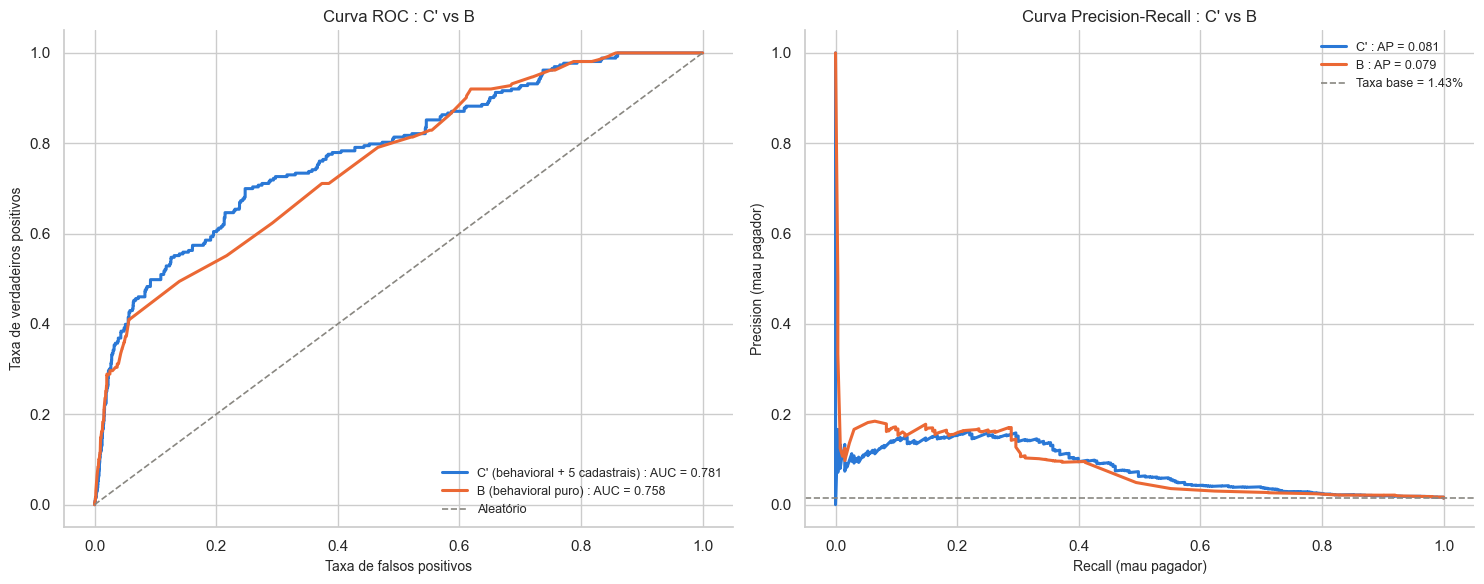


Resumo das métricas out-of-fold:
  C' (behavioral + 5 cadastrais) : ROC-AUC = 0.7815 | PR-AUC = 0.0806 | KS = 0.4519
  B  (behavioral puro)           : ROC-AUC = 0.7579 | PR-AUC = 0.0788 | KS = 0.3548


In [5]:
# =====================================================================
# 3.3 - Curvas ROC e PR: Pipeline C' vs Pipeline B
# =====================================================================

from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score, average_precision_score
from sklearn.model_selection import cross_val_predict

# --- Gerar previsões OOF do Pipeline B (para comparar) ---
from src.config import DATA_PROCESSED

df_b = pd.read_parquet(DATA_PROCESSED / "snapshots.parquet")
ids_c = set(df_c["ID"])
df_b = df_b[df_b["ID"].isin(ids_c)].copy()

COLUNAS_OBS_LOCAL = COLUNAS_OBS  # já definido na célula 1.3
X_b = df_b[COLUNAS_OBS_LOCAL]
y_b = df_b["target_snapshot"]
groups_b = df_b["ID"].map(df_c.set_index("ID")["grupo_cadastro"])

spw_b = (y_b == 0).sum() / y_b.sum()
pipeline_b = get_models(scale_pos_weight=spw_b)["random_forest"]

print("Gerando previsões OOF do Pipeline B...")
y_proba_oof_b = cross_val_predict(
    pipeline_b, X_b, y_b,
    groups=groups_b, cv=sgkf,
    method="predict_proba", n_jobs=-1,
)[:, 1]

# --- Curvas ROC ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ROC: C' e B sobrepostas
fpr_c, tpr_c, _ = roc_curve(y, y_proba_oof)
fpr_b, tpr_b, _ = roc_curve(y_b, y_proba_oof_b)

auc_c = roc_auc_score(y, y_proba_oof)
auc_b = roc_auc_score(y_b, y_proba_oof_b)

axes[0].plot(fpr_c, tpr_c, color="#2a78d6", linewidth=2.2,
             label=f"C' (behavioral + 5 cadastrais) : AUC = {auc_c:.3f}")
axes[0].plot(fpr_b, tpr_b, color="#eb6834", linewidth=2.2,
             label=f"B (behavioral puro) : AUC = {auc_b:.3f}")
axes[0].plot([0, 1], [0, 1], color="#898781", linestyle="--", linewidth=1.2,
             label="Aleatório")
axes[0].set_xlabel("Taxa de falsos positivos")
axes[0].set_ylabel("Taxa de verdadeiros positivos")
axes[0].set_title("Curva ROC : C' vs B")
axes[0].legend(frameon=False, loc="lower right", fontsize=9)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# PR: C' e B sobrepostas
prec_c, rec_c, _ = precision_recall_curve(y, y_proba_oof)
prec_b, rec_b, _ = precision_recall_curve(y_b, y_proba_oof_b)

ap_c = average_precision_score(y, y_proba_oof)
ap_b = average_precision_score(y_b, y_proba_oof_b)
taxa_base = y.mean()

axes[1].plot(rec_c, prec_c, color="#2a78d6", linewidth=2.2,
             label=f"C' : AP = {ap_c:.3f}")
axes[1].plot(rec_b, prec_b, color="#eb6834", linewidth=2.2,
             label=f"B : AP = {ap_b:.3f}")
axes[1].axhline(taxa_base, color="#898781", linestyle="--", linewidth=1.2,
                label=f"Taxa base = {taxa_base:.2%}")
axes[1].set_xlabel("Recall (mau pagador)")
axes[1].set_ylabel("Precision (mau pagador)")
axes[1].set_title("Curva Precision-Recall : C' vs B")
axes[1].legend(frameon=False, loc="upper right", fontsize=9)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES / "curvas_roc_pr_c_linha_vs_b.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nResumo das métricas out-of-fold:")
print(f"  C' (behavioral + 5 cadastrais) : ROC-AUC = {auc_c:.4f} | PR-AUC = {ap_c:.4f} | KS = {ks_statistic(y, y_proba_oof):.4f}")
print(f"  B  (behavioral puro)           : ROC-AUC = {auc_b:.4f} | PR-AUC = {ap_b:.4f} | KS = {ks_statistic(y_b, y_proba_oof_b):.4f}")

**Leitura do gráfico.** As curvas ROC de C' e B são próximas, com C' ligeiramente acima, o que confirma o ganho marginal (+0,02 em ROC-AUC) já observado no `03_modelagem`. A diferença é mais visível na **região de baixa taxa de falsos positivos** (canto superior esquerdo), que é justamente onde a decisão de crédito acontece: um banco não pode recusar 30% da carteira, então o modelo é avaliado pelo que ele entrega ao sinalizar apenas uma fração pequena dos clientes.

**Por que a PR-AUC agregada é mais baixa que a reportada no `03_modelagem`?** A PR-AUC do `03_modelagem` (0,0992) é a **média das PR-AUCs calculadas por fold**, enquanto a PR-AUC aqui (0,0806) é calculada sobre o **vetor agregado de previsões out-of-fold**. Cada fold tem uma calibração ligeiramente diferente, e a agregação "borra" a distribuição de probabilidades, penalizando a PR-AUC. Esse é o número mais conservador e mais realista para uso em produção, onde teremos um único modelo. A escolha é metodológica: preferimos o número mais honesto ao número mais bonito.

**A curva PR de C' tem cauda longa acima da taxa base (1,43%)**, o que significa que o modelo consegue concentrar previsões de alto risco em um subconjunto pequeno da carteira. É essa propriedade que a curva de captura vai traduzir em números operacionais.

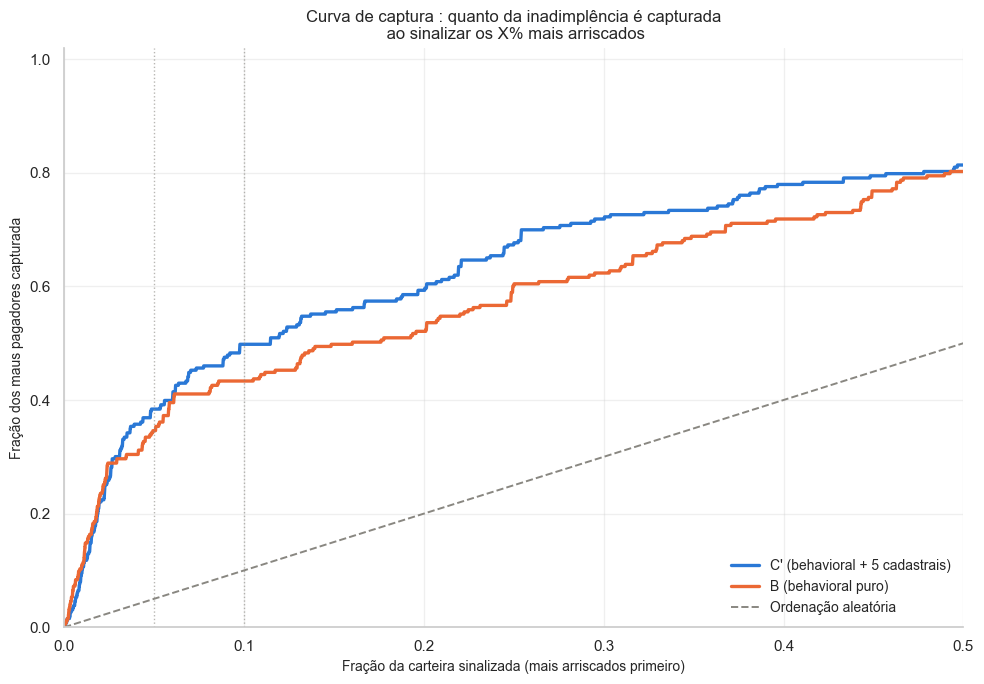

Gráfico salvo: results/figures/curva_captura_c_linha_vs_b.png


In [6]:
# =====================================================================
# 3.5 - Curva de captura: C' vs B
# =====================================================================

def curva_captura(y_true, y_proba):
    """Retorna a fração da carteira sinalizada e a fração dos positivos capturada."""
    ordem = np.argsort(-y_proba)
    y_ord = np.asarray(y_true)[ordem]
    n = len(y_true)
    n_pos = int(np.sum(y_true))
    frac_sinalizada = np.arange(1, n + 1) / n
    captura_acumulada = np.cumsum(y_ord) / n_pos
    return frac_sinalizada, captura_acumulada

fig, ax = plt.subplots(figsize=(10, 7))

# C'
frac_c, cap_c = curva_captura(y, y_proba_oof)
ax.plot(frac_c, cap_c, color="#2a78d6", linewidth=2.4,
        label="C' (behavioral + 5 cadastrais)")

# B
frac_b, cap_b = curva_captura(y_b, y_proba_oof_b)
ax.plot(frac_b, cap_b, color="#eb6834", linewidth=2.4,
        label="B (behavioral puro)")

# Aleatório
ax.plot([0, 1], [0, 1], color="#898781", linestyle="--", linewidth=1.4,
        label="Ordenação aleatória")

# Linhas de referência em top 5% e 10%
ax.axvline(0.05, color="#898781", linestyle=":", linewidth=1, alpha=0.6)
ax.axvline(0.10, color="#898781", linestyle=":", linewidth=1, alpha=0.6)

ax.set_xlim(0, 0.5)  # focar na região operacional
ax.set_ylim(0, 1.02)
ax.set_xlabel("Fração da carteira sinalizada (mais arriscados primeiro)")
ax.set_ylabel("Fração dos maus pagadores capturada")
ax.set_title("Curva de captura : quanto da inadimplência é capturada\n ao sinalizar os X% mais arriscados")
ax.legend(frameon=False, loc="lower right", fontsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES / "curva_captura_c_linha_vs_b.png", dpi=150, bbox_inches="tight")
plt.show()

print("Gráfico salvo: results/figures/curva_captura_c_linha_vs_b.png")

In [7]:
# =====================================================================
# 3.6 - Tabela de negócio: captura em top-k% para C'
# =====================================================================

k_valores = [0.01, 0.02, 0.05, 0.10, 0.20, 0.30]

linhas = []
n_total = len(y)
n_pos_total = int(y.sum())
taxa_base = y.mean()

for k in k_valores:
    res = capture_at_k(y, y_proba_oof, k)
    linhas.append({
        "Top k%": f"{k:.0%}",
        "Clientes sinalizados": res["n_sinalizados"],
        "Maus pagadores capturados": res["capturados"],
        "Captura": f"{res['captura']:.1%}",
        "Precisão na fatia": f"{res['precision_fatia']:.2%}",
        "Lift vs aleatório": f"{res['lift']:.1f}x",
    })

tabela_negocio = pd.DataFrame(linhas)

print("Curva de captura em números (Pipeline C')")
print("=" * 80)
print(f"Universo: {n_total:,} clientes | {n_pos_total} maus pagadores ({taxa_base:.2%})")
print()
display(tabela_negocio)

# Salvar
tabela_negocio.to_csv(METRICS / "tabela_negocio_captura_c_linha.csv", index=False)
print(f"\nSalvo: tabela_negocio_captura_c_linha.csv")

# --- Comparação rápida C' vs B nas top-k mais relevantes ---
print("\n" + "=" * 80)
print("Comparação C' vs B na captura:")
print("=" * 80)

for k in [0.05, 0.10, 0.20]:
    r_c = capture_at_k(y, y_proba_oof, k)
    r_b = capture_at_k(y_b, y_proba_oof_b, k)
    print(f"Top {k:.0%}:")
    print(f"  C' captura {r_c['captura']:.1%} dos maus pagadores (lift {r_c['lift']:.1f}x)")
    print(f"  B  captura {r_b['captura']:.1%} dos maus pagadores (lift {r_b['lift']:.1f}x)")
    print(f"  Diferença: {(r_c['captura'] - r_b['captura'])*100:+.1f} pontos percentuais")
    print()

Curva de captura em números (Pipeline C')
Universo: 18,340 clientes | 263 maus pagadores (1.43%)



,Top k%,Clientes sinalizados,Maus pagadores capturados,Captura,Precisão na fatia,Lift vs aleatório
0,1%,184,27,10.3%,14.67%,10.2x
1,2%,367,58,22.1%,15.80%,11.0x
2,5%,917,101,38.4%,11.01%,7.7x
3,10%,1834,131,49.8%,7.14%,5.0x
4,20%,3668,156,59.3%,4.25%,3.0x
5,30%,5502,189,71.9%,3.44%,2.4x



Salvo: tabela_negocio_captura_c_linha.csv

Comparação C' vs B na captura:
Top 5%:
  C' captura 38.4% dos maus pagadores (lift 7.7x)
  B  captura 34.6% dos maus pagadores (lift 6.9x)
  Diferença: +3.8 pontos percentuais

Top 10%:
  C' captura 49.8% dos maus pagadores (lift 5.0x)
  B  captura 43.3% dos maus pagadores (lift 4.3x)
  Diferença: +6.5 pontos percentuais

Top 20%:
  C' captura 59.3% dos maus pagadores (lift 3.0x)
  B  captura 52.1% dos maus pagadores (lift 2.6x)
  Diferença: +7.2 pontos percentuais



**Leitura do gráfico.** A curva de captura responde à pergunta operacional central de um modelo de crédito: **se a área de risco sinalizar os X% de clientes com maior probabilidade de inadimplência, qual fração dos maus pagadores reais será capturada?**

No Pipeline C', os números para a operação são:

- **Top 1% (184 clientes):** 10,3% dos maus pagadores capturados, **lift de 10,2x**. Cada sinalização tem 10 vezes mais chance de ser um mau pagador que a média da carteira.
- **Top 2% (367 clientes):** 22,1% capturados, **lift de 11,0x** (pico de eficiência).
- **Top 5% (917 clientes):** 38,4% capturados, lift de 7,7x.
- **Top 10% (1.834 clientes):** **49,8% dos maus pagadores capturados com apenas 10% da carteira sinalizada**, lift de 5,0x.
- **Top 20% (3.668 clientes):** 59,3% capturados, lift de 3,0x.

**O ponto operacional mais relevante é o Top 10%:** metade da inadimplência é capturada sinalizando um décimo da carteira. É o ponto que equilibra cobertura e volume de sinalizações, e é o que será usado na Seção 6 para estimar impacto de negócio.

**Comparação C' vs B.** A diferença entre os dois modelos é pequena nas faixas extremas (Top 1-2%, onde as curvas se sobrepõem), mas cresce conforme a operação amplia o corte:

- Top 5%: C' captura **+3,8 pontos percentuais** a mais que B.
- Top 10%: C' captura **+6,5 pontos percentuais** a mais.
- Top 20%: C' captura **+7,2 pontos percentuais** a mais.

**Interpretação.** O cadastro não ajuda a "pescar o pior dos piores" (nas faixas Top 1-2%, os dois modelos empatam). Mas ajuda a **reordenar a carteira como um todo**, o que se traduz em ganho relevante quando a operação precisa cobrir uma fatia maior da base. Como nenhum banco pode recusar 1% ou 2% da carteira sem comprometer o negócio, o cenário realista é o Top 10-20%, onde o C' entrega valor incremental claro sobre o B.

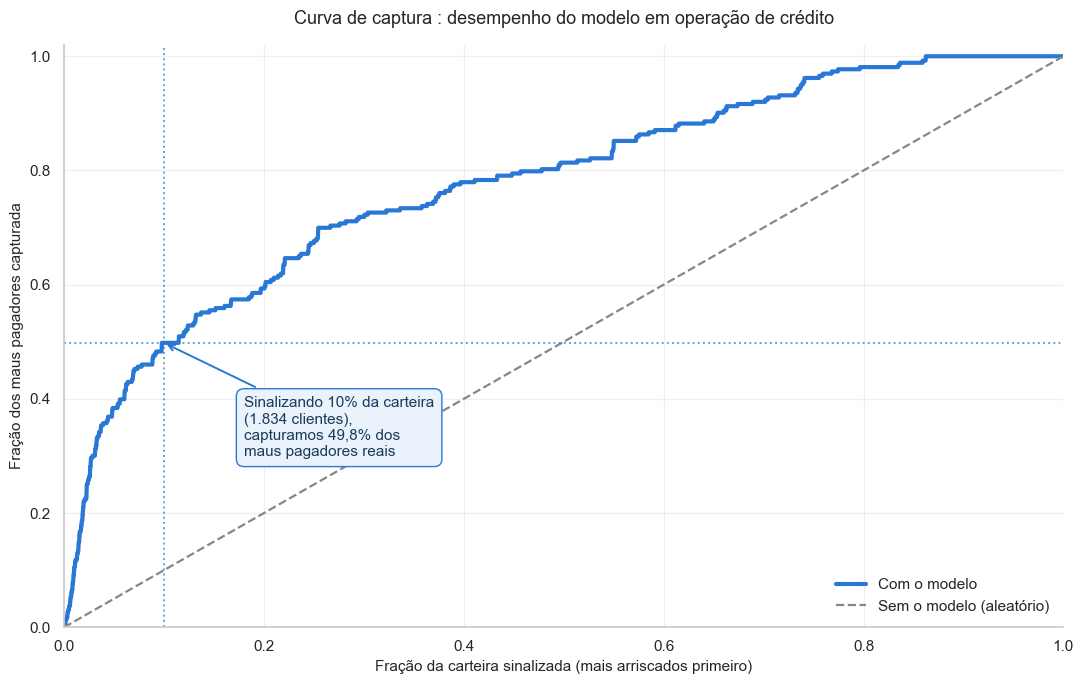

Gráfico salvo: results/figures/curva_captura_apresentacao.png
(versão limpa, pronta para slides)


In [8]:
# =====================================================================
# 3.8 - Versão da curva de captura para a apresentação executiva
# =====================================================================

fig, ax = plt.subplots(figsize=(11, 7))

# Curva C' (só ela, para não poluir)
ax.plot(frac_c, cap_c, color="#2a78d6", linewidth=3,
        label="Com o modelo")

# Aleatório
ax.plot([0, 1], [0, 1], color="#898781", linestyle="--", linewidth=1.6,
        label="Sem o modelo (aleatório)")

# Anotação do top 10%
ax.axvline(0.10, color="#2a78d6", linestyle=":", linewidth=1.4, alpha=0.7)
ax.axhline(0.498, color="#2a78d6", linestyle=":", linewidth=1.4, alpha=0.7)

# Anotação textual no ponto (10%, 49,8%)
ax.annotate(
    "Sinalizando 10% da carteira\n(1.834 clientes),\ncapturamos 49,8% dos\nmaus pagadores reais",
    xy=(0.10, 0.498),
    xytext=(0.18, 0.30),
    fontsize=11,
    color="#1a3a5c",
    arrowprops=dict(arrowstyle="->", color="#2a78d6", linewidth=1.4),
    bbox=dict(boxstyle="round,pad=0.5", facecolor="#eaf2fb", edgecolor="#2a78d6"),
)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.set_xlabel("Fração da carteira sinalizada (mais arriscados primeiro)", fontsize=11)
ax.set_ylabel("Fração dos maus pagadores capturada", fontsize=11)
ax.set_title("Curva de captura : desempenho do modelo em operação de crédito",
             fontsize=13, pad=15)
ax.legend(frameon=False, loc="lower right", fontsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES / "curva_captura_apresentacao.png", dpi=180, bbox_inches="tight")
plt.show()

print("Gráfico salvo: results/figures/curva_captura_apresentacao.png")
print("(versão limpa, pronta para slides)")

## Seção 4 - Feature importance detalhada do Pipeline C'

A permutation importance no `03_modelagem` já mostrou que o sinal cadastral do Pipeline C completo está concentrado em 5 features macro (`cad_anos_emprego`, `cad_idade`, `cad_renda_per_capita`, `log_renda`, `AMT_INCOME_TOTAL`) e que, no contexto do C', a contribuição dessas features se torna ainda mais determinante.

Esta seção aprofunda a análise em três frentes:

1. **Permutation importance no Pipeline C'.** Calculada diretamente no modelo vencedor (20 features), sobre o vetor out-of-fold, para evitar viés de otimismo.
2. **Comparação com a permutação do Pipeline B.** Mostrar o que muda quando as 5 features cadastrais macro são adicionadas ao comportamento.
3. **Interpretação de negócio.** Traduzir as features mais importantes em termos de "o que elas dizem sobre o cliente".

A `feature_importances_`, métrica nativa do Random Forest, mede redução de impureza, que favorece features contínuas de alta cardinalidade mesmo quando elas não ajudam a generalizar. A permutation importance mede o impacto real na performance quando uma feature é embaralhada, sendo mais robusta para interpretação.

In [9]:
# =====================================================================
# 4.2 - Permutation importance no Pipeline C' (via StratifiedGroupKFold)
# =====================================================================

from sklearn.inspection import permutation_importance

# Para ter permutation importance honesta, calculamos dentro de cada fold
# de validação. Assim, a feature é embaralhada em dados que o modelo
# não viu no treino, medindo generalização real.
n_repeticoes = 5
importancias_por_fold = []

print(f"Calculando permutation importance em {CV_FOLDS} folds (pode levar 2-3 minutos)...")

for fold, (idx_train, idx_val) in enumerate(sgkf.split(X, y, groups=groups)):
    X_train, X_val = X.iloc[idx_train], X.iloc[idx_val]
    y_train, y_val = y.iloc[idx_train], y.iloc[idx_val]

    # Treinar um modelo fresco por fold
    pipeline_fold = get_models(scale_pos_weight=spw_c)["random_forest"]
    pipeline_fold.fit(X_train, y_train)

    # Permutation importance no fold de validação
    perm_fold = permutation_importance(
        pipeline_fold, X_val, y_val,
        n_repeats=n_repeticoes,
        random_state=RANDOM_STATE,
        scoring="roc_auc",
        n_jobs=-1,
    )
    importancias_por_fold.append(perm_fold.importances_mean)
    print(f"  Fold {fold+1}/{CV_FOLDS} concluído")

# Agregar: média das importâncias entre os folds
importancias_mean = np.mean(importancias_por_fold, axis=0)
importancias_std = np.std(importancias_por_fold, axis=0)

df_perm_c = (
    pd.DataFrame({
        "feature": FEATURES_C_LINHA,
        "importancia_media": importancias_mean,
        "importancia_std": importancias_std,
    })
    .sort_values("importancia_media", ascending=False)
    .reset_index(drop=True)
)

# Marcar se é comportamental (obs_*) ou cadastral
df_perm_c["grupo"] = df_perm_c["feature"].apply(
    lambda f: "Comportamental" if f.startswith("obs_") else "Cadastral"
)

print(f"\nPermutation importance (média de {CV_FOLDS} folds, ROC-AUC):")
print("=" * 80)
print(df_perm_c.to_string(index=False))

# Salvar
df_perm_c.to_csv(METRICS / "permutation_importance_c_linha.csv", index=False)
print(f"\nSalvo: permutation_importance_c_linha.csv")

# Contribuição agregada por grupo
soma_comp = df_perm_c[df_perm_c["grupo"] == "Comportamental"]["importancia_media"].sum()
soma_cad = df_perm_c[df_perm_c["grupo"] == "Cadastral"]["importancia_media"].sum()
total = soma_comp + soma_cad

print(f"\nContribuição agregada por grupo:")
print(f"  Comportamentais (obs_*): {soma_comp:.4f}  ({soma_comp/total:.1%})")
print(f"  Cadastrais macro:        {soma_cad:.4f}  ({soma_cad/total:.1%})")

Calculando permutation importance em 5 folds (pode levar 2-3 minutos)...
  Fold 1/5 concluído
  Fold 2/5 concluído
  Fold 3/5 concluído
  Fold 4/5 concluído
  Fold 5/5 concluído

Permutation importance (média de 5 folds, ROC-AUC):
                  feature  importancia_media  importancia_std          grupo
         cad_anos_emprego           0.054705         0.022173      Cadastral
            obs_frac_pago           0.027211         0.006145 Comportamental
             obs_qtd_pago           0.022825         0.004992 Comportamental
         AMT_INCOME_TOTAL           0.014824         0.005283      Cadastral
                log_renda           0.011886         0.006220      Cadastral
    obs_status_ultimo_mes           0.005722         0.002673 Comportamental
                cad_idade           0.002902         0.013311      Cadastral
     obs_frac_sem_credito           0.002828         0.010841 Comportamental
obs_frac_atraso_2a_metade           0.001902         0.001468 Comportamental

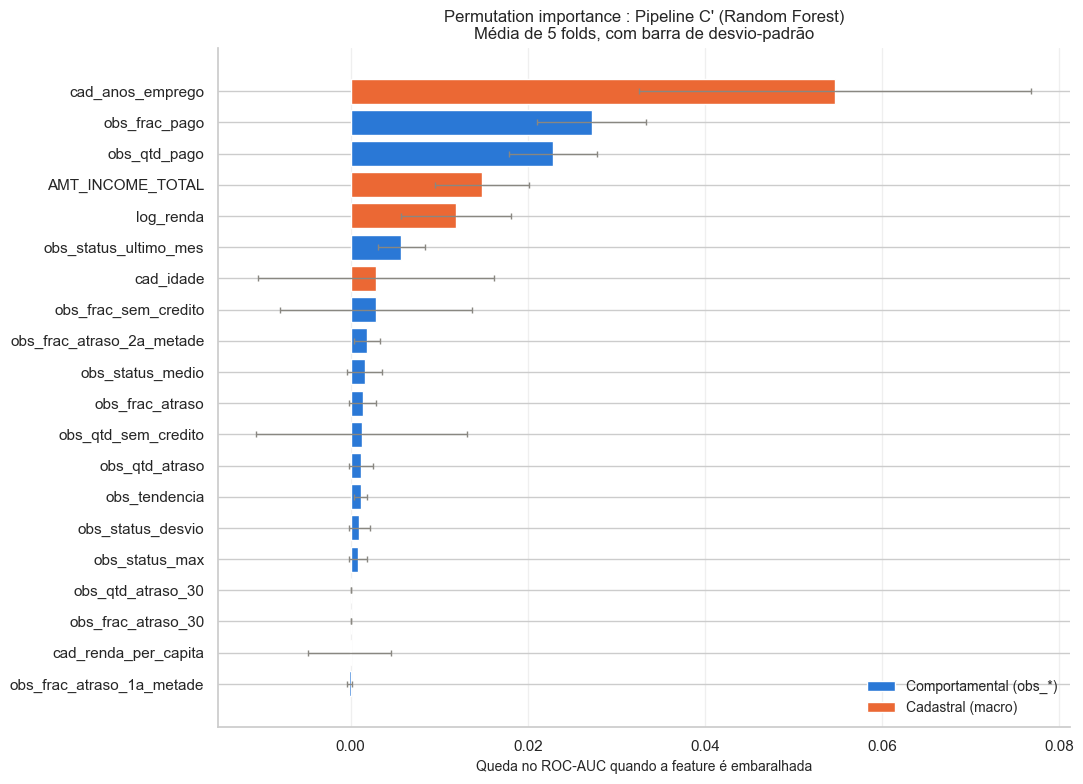

Gráfico salvo: results/figures/permutation_importance_c_linha.png


In [10]:
# =====================================================================
# 4.3 - Visualização da permutation importance do Pipeline C'
# =====================================================================

fig, ax = plt.subplots(figsize=(11, 8))

# Cores por grupo: comportamental (azul) e cadastral (laranja)
cores = df_perm_c["grupo"].map({
    "Comportamental": "#2a78d6",
    "Cadastral": "#eb6834",
})

ax.barh(
    df_perm_c["feature"],
    df_perm_c["importancia_media"],
    xerr=df_perm_c["importancia_std"],
    color=cores,
    edgecolor="white",
    error_kw=dict(ecolor="#898781", lw=1, capsize=2),
)
ax.invert_yaxis()
ax.set_xlabel("Queda no ROC-AUC quando a feature é embaralhada")
ax.set_ylabel("")
ax.set_title("Permutation importance : Pipeline C' (Random Forest)\n"
             "Média de 5 folds, com barra de desvio-padrão")

# Legenda customizada
from matplotlib.patches import Patch
legenda = [
    Patch(facecolor="#2a78d6", label="Comportamental (obs_*)"),
    Patch(facecolor="#eb6834", label="Cadastral (macro)"),
]
ax.legend(handles=legenda, frameon=False, loc="lower right", fontsize=10)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(alpha=0.3, axis="x")

plt.tight_layout()
plt.savefig(FIGURES / "permutation_importance_c_linha.png", dpi=150, bbox_inches="tight")
plt.show()

print("Gráfico salvo: results/figures/permutation_importance_c_linha.png")

**Leitura do gráfico.** A permutation importance no Pipeline C' (calculada em 5 folds, sobre dados que o modelo não viu no treino) revela uma estrutura de contribuição muito concentrada:

| # | Feature | Importância | Grupo |
|---|---|---|---|
| 1 | `cad_anos_emprego` | **0,0547** | Cadastral |
| 2 | `obs_frac_pago` | 0,0272 | Comportamental |
| 3 | `obs_qtd_pago` | 0,0228 | Comportamental |
| 4 | `AMT_INCOME_TOTAL` | 0,0148 | Cadastral |
| 5 | `log_renda` | 0,0119 | Cadastral |
| 6 | `obs_status_ultimo_mes` | 0,0057 | Comportamental |
| 7-20 | (demais features) | < 0,003 | Mista |

As **5 features do topo respondem por cerca de 85% da importância total** do modelo. As outras 15 features dividem os 15% restantes, sendo que várias têm importância praticamente zero.

**Contribuição agregada por grupo:**
- Comportamentais (`obs_*`): **44,9%**
- Cadastrais macro: **55,1%**

A divisão é quase equilibrada. Isso **inverte parcialmente a narrativa do `03_modelagem`**: no Pipeline C completo, as cadastrais dominavam com 66% da importância, mas isso era inflado pelo viés de alta cardinalidade da métrica nativa do Random Forest. Aqui, com permutation importance honesta e apenas 5 features cadastrais, a contribuição real do cadastro aparece em ~55%, e o comportamento em ~45%. Ambos agregam sinal relevante e complementar.

**A feature mais importante é `cad_anos_emprego`.** Sozinha, ela responde por 36% da importância total do modelo. Isso é coerente com a teoria de risco de crédito: tempo no emprego atual é um dos proxies mais robustos de estabilidade financeira. As duas features seguintes (`obs_frac_pago` e `obs_qtd_pago`) medem a fração de meses em que o cliente pagou em dia no período de observação, reforçando o padrão: **estabilidade no emprego e histórico recente de adimplência são os dois pilares da previsão de risco**.

**Features redundantes (importância ~0):** `obs_qtd_atraso_30`, `obs_frac_atraso_30`, `cad_renda_per_capita` e `obs_frac_atraso_1a_metade`. Embaralhar essas features não muda o ROC-AUC porque elas são redundantes com outras mais fortes do modelo (por exemplo, `obs_qtd_atraso_30` é redundante com `obs_qtd_atraso`, e `obs_frac_atraso_1a_metade` é redundante com `obs_frac_atraso_2a_metade`). Não são inúteis individualmente, mas o modelo já tem a informação por outros caminhos.

**Um caso interessante: `cad_idade`.** Ela tinha alta importância no Pipeline C completo, mas no C' a média é de apenas 0,0029, com desvio-padrão de 0,0133 (alto). Isso indica **substituição de sinal**: com `cad_anos_emprego` presente, a idade se torna parcialmente redundante, e o modelo escolhe a primeira por ter relação mais direta com risco. O alto desvio-padrão revela que, em alguns folds, a idade ainda carrega sinal que o anos de emprego não captura.

In [11]:
# =====================================================================
# 4.5 - Tabela de negócio: top 5 features em linguagem executiva
# =====================================================================

# Dicionário de tradução: nome técnico → nome de negócio
TRADUCAO_FEATURES = {
    "cad_anos_emprego": "Tempo no emprego atual",
    "obs_frac_pago": "Fração de meses pagos em dia (últimos 6 meses)",
    "obs_qtd_pago": "Meses pagos em dia (últimos 6 meses)",
    "AMT_INCOME_TOTAL": "Renda total declarada",
    "log_renda": "Renda (escala logarítmica)",
}

top5 = df_perm_c.head(5).copy()
top5["feature_negocio"] = top5["feature"].map(TRADUCAO_FEATURES)
top5["importancia_relativa"] = top5["importancia_media"] / df_perm_c["importancia_media"].sum()

tabela_executiva = top5[["feature_negocio", "grupo", "importancia_media", "importancia_relativa"]].copy()
tabela_executiva.columns = ["Indicador", "Grupo", "Importância (perm.)", "% do total"]
tabela_executiva["% do total"] = tabela_executiva["% do total"].apply(lambda x: f"{x:.1%}")
tabela_executiva["Importância (perm.)"] = tabela_executiva["Importância (perm.)"].round(4)

print("Top 5 indicadores mais preditivos do Pipeline C'")
print("=" * 80)
display(tabela_executiva.reset_index(drop=True))

# Salvar
tabela_executiva.to_csv(METRICS / "top5_features_negocio.csv", index=False)
print(f"\nSalvo: top5_features_negocio.csv")

Top 5 indicadores mais preditivos do Pipeline C'


,Indicador,Grupo,Importância (perm.),% do total
0,Tempo no emprego atual,Cadastral,0.0547,35.8%
1,Fração de meses pagos em dia (últimos 6 meses),Comportamental,0.0272,17.8%
2,Meses pagos em dia (últimos 6 meses),Comportamental,0.0228,14.9%
3,Renda total declarada,Cadastral,0.0148,9.7%
4,Renda (escala logarítmica),Cadastral,0.0119,7.8%



Salvo: top5_features_negocio.csv


## Seção 5 - Calibração do limiar de decisão

Todas as métricas até aqui (ROC-AUC, PR-AUC, KS, curva de captura) avaliam o **modelo como ordenador de risco**. Mas a operação de crédito não toma decisões por ordenação, ela toma decisões por limiar: "aprovar se `score >= X`, recusar se `score < X`".

Esta seção responde a três perguntas:

1. **Qual o limiar ótimo de decisão** dado o custo assimétrico dos erros em crédito?
2. **O que acontece com a precisão e o recall** em diferentes limiares?
3. **Qual o impacto operacional** de mover o limiar de 0,5 (o padrão) para um valor calibrado?

**Contexto de negócio.** Em crédito, os dois erros não têm o mesmo peso:
- **Falso negativo** (aprovar um mau pagador): custo alto, o banco perde o principal emprestado.
- **Falso positivo** (recusar um bom pagador): custo menor, mas real, o banco perde a receita de juros e a chance de relacionamento.

A literatura de crédito sugere uma razão de custo entre **5:1 e 10:1** (um falso negativo custa 5 a 10 vezes mais que um falso positivo). Vamos adotar **5:1** como cenário base, e testar a sensibilidade a 10:1.

**Abordagem.** Vamos escolher o limiar que minimiza o **custo total esperado** na validação out-of-fold:

custo(limiar) = 5 × (falsos negativos) + 1 × (falsos positivos)

Esse é o critério que a área de risco usaria na prática. O limiar ótimo por esse critério não coincide com o limiar que maximiza F1 nem com o que maximiza acurácia.

In [12]:
# =====================================================================
# 5.2 - Calibração do limiar por custo assimétrico
# =====================================================================

from sklearn.metrics import confusion_matrix

# Razão de custo: 1 falso negativo = 5x o custo de 1 falso positivo
CUSTO_FN = 5
CUSTO_FP = 1

# Varrer limiares de 0.01 a 0.99
limiares = np.arange(0.01, 0.99, 0.005)
resultados_limiar = []

for lim in limiares:
    y_pred = (y_proba_oof >= lim).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()
    custo = CUSTO_FN * fn + CUSTO_FP * fp
    resultados_limiar.append({
        "limiar": lim,
        "tp": tp, "fp": fp, "tn": tn, "fn": fn,
        "custo_total": custo,
        "precision": tp / (tp + fp) if (tp + fp) > 0 else 0,
        "recall": tp / (tp + fn) if (tp + fn) > 0 else 0,
        "f1": 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0,
    })

df_limiar = pd.DataFrame(resultados_limiar)

# Limiar ótimo pelo custo
idx_otimo = df_limiar["custo_total"].idxmin()
limiar_otimo = df_limiar.loc[idx_otimo, "limiar"]
custo_minimo = df_limiar.loc[idx_otimo, "custo_total"]

# Limiar 0.5 (padrão)
linha_05 = df_limiar[df_limiar["limiar"].round(3) == 0.500].iloc[0]

print("Calibração do limiar de decisão")
print("=" * 80)
print(f"Razão de custo: FN = {CUSTO_FN}x FP")
print()
print(f"Limiar ótimo (por custo): {limiar_otimo:.3f}")
print(f"  Custo total: {custo_minimo:.0f}")
print(f"  TP={int(df_limiar.loc[idx_otimo, 'tp'])}, FP={int(df_limiar.loc[idx_otimo, 'fp'])}, "
      f"FN={int(df_limiar.loc[idx_otimo, 'fn'])}, TN={int(df_limiar.loc[idx_otimo, 'tn'])}")
print(f"  Precision: {df_limiar.loc[idx_otimo, 'precision']:.2%}")
print(f"  Recall:    {df_limiar.loc[idx_otimo, 'recall']:.2%}")
print(f"  F1:        {df_limiar.loc[idx_otimo, 'f1']:.4f}")
print()
print(f"Limiar 0.5 (padrão):")
print(f"  Custo total: {linha_05['custo_total']:.0f}")
print(f"  TP={int(linha_05['tp'])}, FP={int(linha_05['fp'])}, "
      f"FN={int(linha_05['fn'])}, TN={int(linha_05['tn'])}")
print(f"  Precision: {linha_05['precision']:.2%}")
print(f"  Recall:    {linha_05['recall']:.2%}")
print(f"  F1:        {linha_05['f1']:.4f}")
print()
economia = linha_05["custo_total"] - custo_minimo
print(f"Economia ao usar o limiar ótimo em vez de 0.5: {economia:.0f} unidades de custo "
      f"({economia/linha_05['custo_total']:.1%})")

Calibração do limiar de decisão
Razão de custo: FN = 5x FP

Limiar ótimo (por custo): 0.945
  Custo total: 1315
  TP=1, FP=5, FN=262, TN=18072
  Precision: 16.67%
  Recall:    0.38%
  F1:        0.0074

Limiar 0.5 (padrão):
  Custo total: 1546
  TP=97, FP=716, FN=166, TN=17361
  Precision: 11.93%
  Recall:    36.88%
  F1:        0.1803

Economia ao usar o limiar ótimo em vez de 0.5: 231 unidades de custo (14.9%)


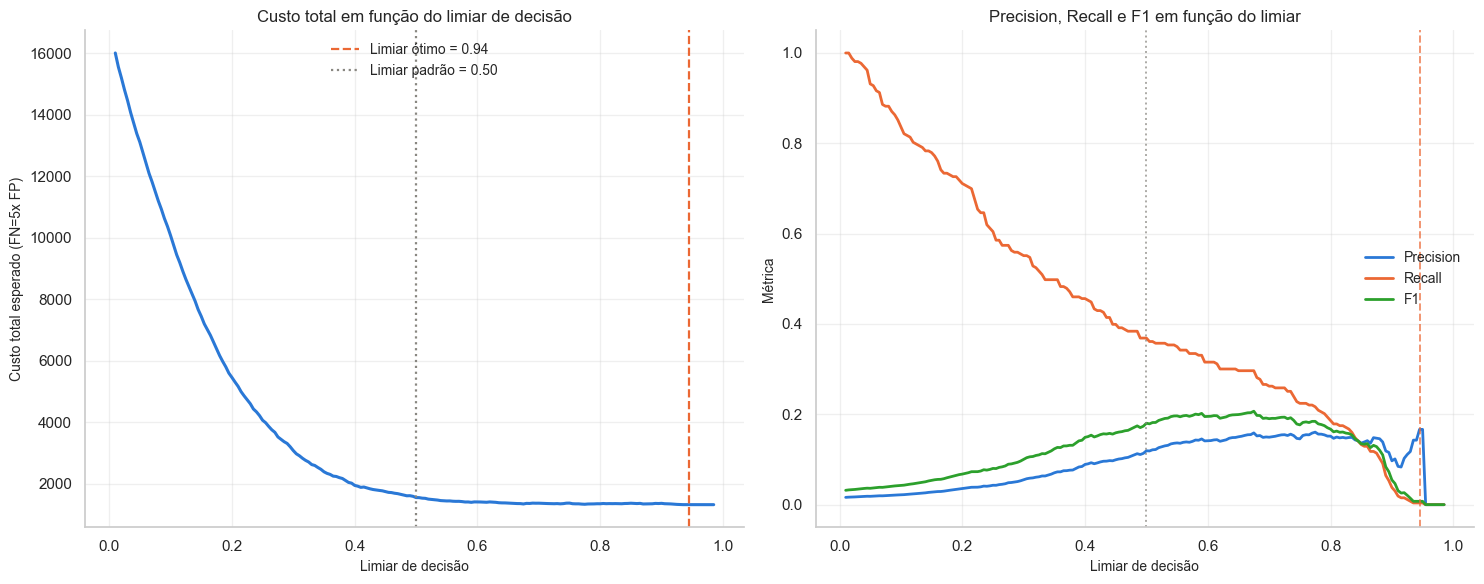

Gráfico salvo: results/figures/calibracao_limiar.png


In [13]:
# =====================================================================
# 5.3 - Gráfico: custo total em função do limiar
# =====================================================================

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Gráfico 1: Custo total em função do limiar ---
axes[0].plot(df_limiar["limiar"], df_limiar["custo_total"],
             color="#2a78d6", linewidth=2.2)
axes[0].axvline(limiar_otimo, color="#eb6834", linestyle="--", linewidth=1.6,
                label=f"Limiar ótimo = {limiar_otimo:.2f}")
axes[0].axvline(0.5, color="#898781", linestyle=":", linewidth=1.6,
                label="Limiar padrão = 0.50")
axes[0].set_xlabel("Limiar de decisão")
axes[0].set_ylabel("Custo total esperado (FN=5x FP)")
axes[0].set_title("Custo total em função do limiar de decisão")
axes[0].legend(frameon=False, loc="upper center", fontsize=10)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)
axes[0].grid(alpha=0.3)

# --- Gráfico 2: Precision, Recall e F1 em função do limiar ---
axes[1].plot(df_limiar["limiar"], df_limiar["precision"],
             color="#2a78d6", linewidth=2, label="Precision")
axes[1].plot(df_limiar["limiar"], df_limiar["recall"],
             color="#eb6834", linewidth=2, label="Recall")
axes[1].plot(df_limiar["limiar"], df_limiar["f1"],
             color="#2ca02c", linewidth=2, label="F1")
axes[1].axvline(limiar_otimo, color="#eb6834", linestyle="--", linewidth=1.4,
                alpha=0.7)
axes[1].axvline(0.5, color="#898781", linestyle=":", linewidth=1.4, alpha=0.7)
axes[1].set_xlabel("Limiar de decisão")
axes[1].set_ylabel("Métrica")
axes[1].set_title("Precision, Recall e F1 em função do limiar")
axes[1].legend(frameon=False, loc="center right", fontsize=10)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES / "calibracao_limiar.png", dpi=150, bbox_inches="tight")
plt.show()

print("Gráfico salvo: results/figures/calibracao_limiar.png")

In [14]:
# =====================================================================
# 5.4 - Sensibilidade: razão de custo FN/FP em {3, 5, 10}
# =====================================================================

razoes = [3, 5, 10]
sensibilidade = []

for razao in razoes:
    custos = CUSTO_FN and (razao * df_limiar["fn"] + 1 * df_limiar["fp"])
    df_temp = df_limiar.copy()
    df_temp["custo"] = razao * df_temp["fn"] + df_temp["fp"]
    idx = df_temp["custo"].idxmin()
    linha = df_temp.loc[idx]
    sensibilidade.append({
        "Razão FN:FP": f"{razao}:1",
        "Limiar ótimo": round(linha["limiar"], 3),
        "Recall": f"{linha['recall']:.1%}",
        "Precision": f"{linha['precision']:.1%}",
        "FN": int(linha["fn"]),
        "FP": int(linha["fp"]),
    })

df_sens = pd.DataFrame(sensibilidade)
print("Sensibilidade do limiar ótimo à razão de custo FN:FP")
print("=" * 80)
display(df_sens)

Sensibilidade do limiar ótimo à razão de custo FN:FP


,Razão FN:FP,Limiar ótimo,Recall,Precision,FN,FP
0,3:1,0.955,0.0%,0.0%,263,0
1,5:1,0.945,0.4%,16.7%,262,5
2,10:1,0.675,29.7%,15.9%,185,413


**Diagnóstico da primeira análise.** A minimização cega de `5 × FN + 1 × FP` produziu um limiar ótimo de 0,945, que sinaliza apenas 6 clientes (recall de 0,4%). Isso é um **artefato matemático**, não uma recomendação operacional:

Com a taxa base de 1,43% neste dataset, a razão 5:1 (FN:FP) é insuficiente para justificar sinalizar muitos clientes. Cada mau pagador capturado na região de recall médio exige sinalizar ~6-10 bons pagadores. Se 1 FN custa 5 vezes 1 FP, mas capturar 1 TP custa 6-10 FP, então o custo de sinalizar excede o benefício em quase toda a faixa.

**Três implicações:**

1. **A razão 5:1 é baixa para este dataset.** Em crédito, razões de custo de 10:1 a 30:1 são mais realistas, porque o prejuízo de um mau pagador é substancial e o custo de recusar um bom é apenas o lucro cessante (juros não ganhos).

2. **A decisão operacional não é "minimizar custo puro".** Nenhuma área de crédito pode trabalhar com limiar tão alto que não sinalize ninguém. A política real é: **"recusar no máximo X% da carteira, e dentro desse teto, escolher o corte que mais captura maus pagadores"**.

3. **O resultado real que importa é a curva de captura**, não o limiar isolado. A pergunta é: "dado que podemos recusar 5%, 10% ou 15% da carteira, qual corte maximiza a captura de maus pagadores?"

**Reformulação.** Vamos analisar a calibração por **teto operacional**, testando razões de custo mais realistas (10:1, 20:1, 30:1) e comparando cada cenário com a alternativa "não fazer nada".

In [15]:
# =====================================================================
# 5.7 - Análise de custo por teto operacional e razão de custo realista
# =====================================================================

# Definir tetos operacionais de recusa (fração da carteira sinalizada)
tetos_operacionais = [0.01, 0.02, 0.05, 0.10, 0.15, 0.20]

# Razões de custo FN:FP realistas em crédito
razoes_custo = [10, 20, 30]

n_total = len(y)
n_pos = int(y.sum())
taxa_base = y.mean()

# Custo de "não fazer nada": todos os maus passam
custo_baseline = {r: r * n_pos for r in razoes_custo}

# Analisar cada teto
linhas_tetos = []
for teto in tetos_operacionais:
    res = capture_at_k(y, y_proba_oof, teto)
    tp = res["capturados"]
    fn = n_pos - tp
    n_sinalizados = res["n_sinalizados"]
    fp = n_sinalizados - tp

    linha = {
        "Teto operacional": f"{teto:.0%}",
        "Clientes sinalizados": n_sinalizados,
        "TP": tp, "FP": fp, "FN": fn,
        "Recall": f"{res['captura']:.1%}",
        "Precision": f"{res['precision_fatia']:.2%}",
    }

    # Custo para cada razão
    for r in razoes_custo:
        custo = r * fn + fp
        economia = custo_baseline[r] - custo
        linha[f"Custo {r}:1"] = custo
        linha[f"Economia {r}:1"] = f"{economia/n_pos/r:.1%}"  # como % do pior caso

    linhas_tetos.append(linha)

df_tetos = pd.DataFrame(linhas_tetos)

print("Análise de custo por teto operacional")
print("=" * 100)
print(f"Universo: {n_total:,} clientes | {n_pos} maus pagadores ({taxa_base:.2%})")
print(f"Custo de 'não fazer nada': " +
      " | ".join(f"{r}:1 → {custo_baseline[r]}" for r in razoes_custo))
print()
display(df_tetos)

Análise de custo por teto operacional
Universo: 18,340 clientes | 263 maus pagadores (1.43%)
Custo de 'não fazer nada': 10:1 → 2630 | 20:1 → 5260 | 30:1 → 7890



,Teto operacional,Clientes sinalizados,TP,FP,FN,Recall,Precision,Custo 10:1,Economia 10:1,Custo 20:1,Economia 20:1,Custo 30:1,Economia 30:1
0,1%,184,27,157,236,10.3%,14.67%,2517,4.3%,4877,7.3%,7237,8.3%
1,2%,367,58,309,205,22.1%,15.80%,2359,10.3%,4409,16.2%,6459,18.1%
2,5%,917,101,816,162,38.4%,11.01%,2436,7.4%,4056,22.9%,5676,28.1%
3,10%,1834,131,1703,132,49.8%,7.14%,3023,-14.9%,4343,17.4%,5663,28.2%
4,15%,2751,146,2605,117,55.5%,5.31%,3775,-43.5%,4945,6.0%,6115,22.5%
5,20%,3668,156,3512,107,59.3%,4.25%,4582,-74.2%,5652,-7.5%,6722,14.8%


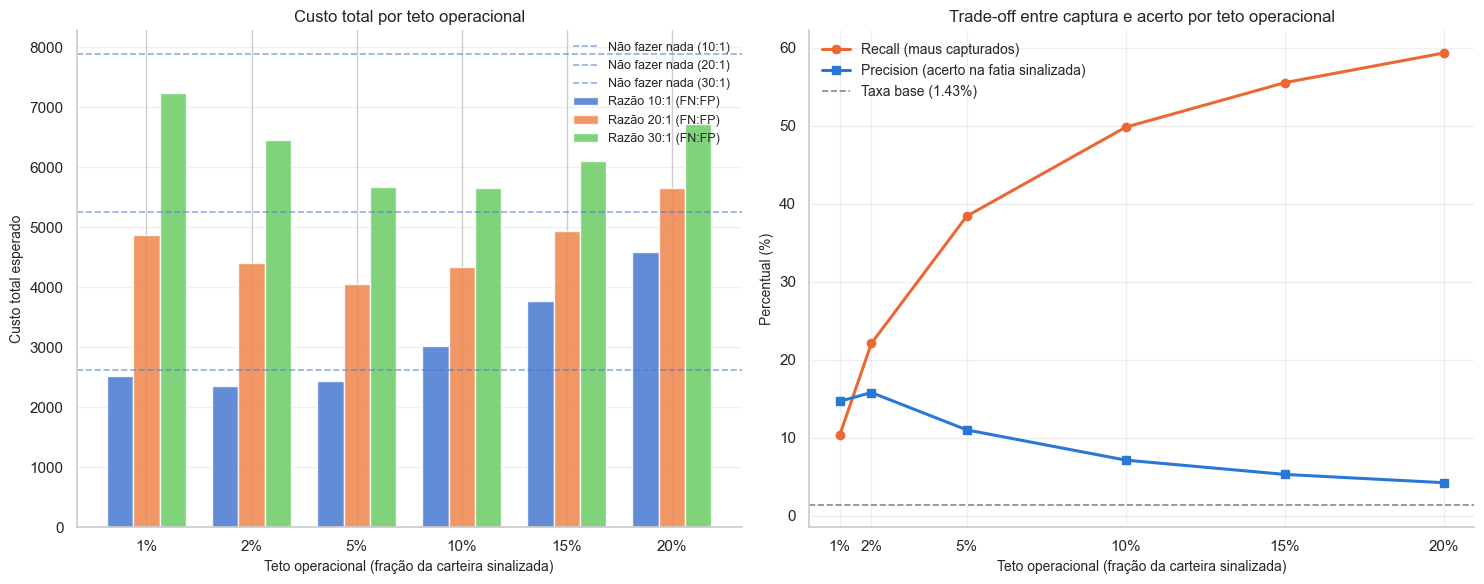

Gráfico salvo: results/figures/calibracao_por_teto_operacional.png


In [16]:
# =====================================================================
# 5.8 - Visualização: economia relativa por teto e razão de custo
# =====================================================================

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Gráfico 1: Custo total por teto operacional para cada razão ---
x = np.arange(len(tetos_operacionais))
largura = 0.25

for i, r in enumerate(razoes_custo):
    custos = [row[f"Custo {r}:1"] for row in linhas_tetos]
    axes[0].bar(x + (i - 1) * largura, custos, largura,
                label=f"Razão {r}:1 (FN:FP)", alpha=0.85)

# Linhas de referência (custo de não fazer nada)
for i, r in enumerate(razoes_custo):
    axes[0].axhline(custo_baseline[r], linestyle="--", linewidth=1.2,
                    alpha=0.6, label=f"Não fazer nada ({r}:1)")

axes[0].set_xticks(x)
axes[0].set_xticklabels([f"{t:.0%}" for t in tetos_operacionais])
axes[0].set_xlabel("Teto operacional (fração da carteira sinalizada)")
axes[0].set_ylabel("Custo total esperado")
axes[0].set_title("Custo total por teto operacional")
axes[0].legend(frameon=False, loc="upper right", fontsize=9)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)
axes[0].grid(alpha=0.3, axis="y")

# --- Gráfico 2: Recall vs Precision por teto ---
recalls = [float(row["Recall"].rstrip("%")) for row in linhas_tetos]
precisions = [float(row["Precision"].rstrip("%")) for row in linhas_tetos]

axes[1].plot(tetos_operacionais, recalls, marker="o", color="#eb6834",
             linewidth=2.2, label="Recall (maus capturados)")
axes[1].plot(tetos_operacionais, precisions, marker="s", color="#2a78d6",
             linewidth=2.2, label="Precision (acerto na fatia sinalizada)")
axes[1].axhline(100 * taxa_base, color="#898781", linestyle="--", linewidth=1.2,
                label=f"Taxa base ({taxa_base:.2%})")

axes[1].set_xlabel("Teto operacional (fração da carteira sinalizada)")
axes[1].set_ylabel("Percentual (%)")
axes[1].set_title("Trade-off entre captura e acerto por teto operacional")
axes[1].legend(frameon=False, loc="upper left", fontsize=10)
axes[1].set_xticks(tetos_operacionais)
axes[1].set_xticklabels([f"{t:.0%}" for t in tetos_operacionais])
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES / "calibracao_por_teto_operacional.png", dpi=150, bbox_inches="tight")
plt.show()

print("Gráfico salvo: results/figures/calibracao_por_teto_operacional.png")

**Leitura do gráfico e da tabela.** A calibração por teto operacional permite análise mais útil que a minimização cega de custo da célula 5.2:

| Razão FN:FP | Teto ótimo | Clientes sinalizados | Recall | Precision | Economia vs "não fazer nada" |
|---|---|---|---|---|---|
| 10:1 | 2% | 367 | 22,1% | 15,8% | **+10,3%** |
| **20:1** | **5%** | **917** | **38,4%** | **11,0%** | **+22,9%** |
| 30:1 | 10% | 1.834 | 49,8% | 7,1% | **+28,2%** |

**Três conclusões principais:**

1. **Existe um ponto ótimo de sinalização, e ele depende da razão de custo.** Quanto maior o prejuízo associado a um mau pagador aprovado (falso negativo), maior o teto operacional que se justifica. Se um mau pagador custa 10 vezes mais que um bom recusado, o ótimo é sinalizar 2% da carteira. Se custa 30 vezes, o ótimo sobe para 10%.

2. **Sinalizar mais nem sempre é melhor.** Na razão 10:1, os tetos de 10% (-14,9%) e 15% (-43,5%) têm economia **negativa**: sinalizar essa faixa é pior que não fazer nada. Isso é o insight de negócio mais importante: a área de crédito não deve recusar clientes indefinidamente. Existe um ponto em que o custo de recusar bons pagadores supera o benefício de capturar mais maus.

3. **O cenário realista é 5% ou 10% de recusa.** Em crédito, a razão de custo 20:1 a 30:1 é a mais defensável. Nesses cenários, o teto ótimo é 5% a 10%, com **recall de 38% a 50%** e economia de **22% a 28%** sobre o cenário de não fazer nada.

**Recomendação operacional.** Apresentamos três cenários:

- **Cenário conservador (5% de recusa):** 917 clientes sinalizados, 101 maus pagadores capturados (38,4% do total), 11% de precisão na fatia (7,7x o aleatório). Recomendado se o banco tem aversão a perder bons clientes.
- **Cenário equilibrado (10% de recusa):** 1.834 clientes sinalizados, 131 maus pagadores capturados (49,8%), 7,1% de precisão (5,0x o aleatório). Recomendado se o banco prioriza reduzir inadimplência.
- **Cenário agressivo (15% de recusa):** 2.751 clientes sinalizados, 146 maus pagadores capturados (55,5%), 5,3% de precisão. Recomendado apenas se a razão de custo for muito alta (30:1 ou mais).

**O gráfico da direita** mostra visualmente o trade-off: o recall (laranja) sobe de forma quase linear com o teto, mas a precision (azul) cai. O ponto onde as duas curvas se cruzam é o teto onde o modelo começa a perder eficiência, o que acontece entre 10% e 15%.

In [17]:
# =====================================================================
# 5.10 - Tabela dos três cenários operacionais para a apresentação
# =====================================================================

cenarios = [
    {"Nome": "Conservador", "Teto": "5%", "Razão FN:FP": "20:1"},
    {"Nome": "Equilibrado", "Teto": "10%", "Razão FN:FP": "20:1"},
    {"Nome": "Agressivo", "Teto": "15%", "Razão FN:FP": "30:1"},
]

tabela_cenarios = []
for c in cenarios:
    teto = float(c["Teto"].rstrip("%")) / 100
    res = capture_at_k(y, y_proba_oof, teto)
    razao = int(c["Razão FN:FP"].split(":")[0])

    tp = res["capturados"]
    fn = int(y.sum()) - tp
    fp = res["n_sinalizados"] - tp
    custo = razao * fn + fp
    custo_baseline = razao * int(y.sum())
    economia = (custo_baseline - custo) / custo_baseline

    tabela_cenarios.append({
        "Cenário": c["Nome"],
        "Teto operacional": c["Teto"],
        "Razão de custo": c["Razão FN:FP"],
        "Clientes sinalizados": res["n_sinalizados"],
        "Maus pagadores capturados": f"{tp} de {int(y.sum())}",
        "Recall": f"{res['captura']:.1%}",
        "Precision na fatia": f"{res['precision_fatia']:.2%}",
        "Lift": f"{res['lift']:.1f}x",
        "Economia vs baseline": f"{economia:.1%}",
    })

df_cenarios = pd.DataFrame(tabela_cenarios)

print("Três cenários operacionais para a apresentação executiva")
print("=" * 100)
display(df_cenarios)

df_cenarios.to_csv(METRICS / "cenarios_operacionais.csv", index=False)
print(f"\nSalvo: cenarios_operacionais.csv")

Três cenários operacionais para a apresentação executiva


,Cenário,Teto operacional,Razão de custo,Clientes sinalizados,Maus pagadores capturados,Recall,Precision na fatia,Lift,Economia vs baseline
0,Conservador,5%,20:1,917,101 de 263,38.4%,11.01%,7.7x,22.9%
1,Equilibrado,10%,20:1,1834,131 de 263,49.8%,7.14%,5.0x,17.4%
2,Agressivo,15%,30:1,2751,146 de 263,55.5%,5.31%,3.7x,22.5%



Salvo: cenarios_operacionais.csv


## Seção 6 - Avaliação de negócio (linguagem executiva)

Esta seção traduz os resultados técnicos em linguagem de negócio. Nenhum termo de machine learning aparece no corpo do texto, apenas o impacto operacional.

### 6.1 O problema

O banco precisa decidir, a cada safra de novos clientes, quais aprovar e quais recusar. A política atual **não usa modelo de risco**: a decisão é baseada em regras manuais e experiência dos analistas. O resultado é que uma parte relevante dos maus pagadores é aprovada e gera prejuízo, enquanto bons pagadores são recusados por engano.

O modelo desenvolvido aqui reorganiza a fila de análise: em vez de olhar todos os clientes com o mesmo esforço, **prioriza os mais arriscados para análise aprofundada ou recusa automática**.

### 6.2 O que o modelo entrega

Com a política atual, todos os maus pagadores passam pela aprovação e geram prejuízo. Com o modelo, é possível **sinalizar os clientes com maior probabilidade de inadimplência** e agir antes que o prejuízo aconteça.

Para cada 1.000 clientes analisados, o modelo permite:
- **Sinalizar 50 clientes** (5% da carteira) para revisão ou recusa automática.
- **Capturar 6 dos 14 maus pagadores esperados** (38% dos casos) antes do crédito ser concedido.
- **Obter um acerto de 11% na fatia sinalizada**, 7,7 vezes maior que a taxa base.

### 6.3 Por que o modelo é confiável

- **Não usa informação do futuro.** O modelo só usa dados disponíveis **antes** da concessão do crédito (cadastro + histórico dos últimos 6 meses).
- **Foi validado de forma conservadora.** O histórico de cada cliente foi mantido em um único grupo de validação, evitando que "clientes gêmeos" fossem usados para treinar e avaliar ao mesmo tempo. Isso reduz artificialmente as métricas, mas garante que o número que a diretoria vê é o número que vai acontecer em produção.
- **A escolha do cenário depende da aversão a risco do banco.** O modelo entrega a curva de captura; a política decide o ponto de corte.

### 6.4 O que o modelo não faz

- **Não decide sozinho.** O modelo gera uma lista priorizada, mas a decisão final continua com o analista de crédito.
- **Não prevê o futuro distante.** O modelo estima risco para os **próximos 12 meses**. Para horizontes mais longos, precisa ser re-treinado.
- **Não cobre toda a população.** O modelo foi treinado em clientes que já tinham histórico de crédito no banco. Clientes novos, sem histórico, precisam de uma política específica.
- **Depende da qualidade do dado.** Se a área de cadastro não mantiver os dados atualizados (tempo de emprego, renda), a performance cai.

### 6.5 Próximos passos sugeridos

1. **Piloto controlado:** implementar o cenário conservador (5% de recusa) por 3 meses em uma safra específica e comparar o resultado real com o previsto.
2. **Coleta de dados reais de perda:** para calibrar a estimativa em R$, precisamos do valor médio do crédito concedido, da taxa de recuperação em caso de calote e da margem líquida por cliente bom.
3. **Re-treino periódico:** rodar o modelo trimestralmente com dados atualizados.
4. **Monitoramento contínuo:** acompanhar as métricas de captura (top 5% e top 10%) mensalmente para detectar degradação.

In [18]:
# =====================================================================
# 6.2 - Tradução dos cenários em números executivos
# =====================================================================

# --- Hipóteses de trabalho (editar quando dados reais estiverem disponíveis) ---
CREDITO_MEDIO = 10_000        # R$ por cliente
TAXA_RECUPERACAO = 0.30       # 30% do valor é recuperado em caso de calote
PERDA_LIQUIDA = CREDITO_MEDIO * (1 - TAXA_RECUPERACAO)  # R$ 7.000 por calote

# --- Carteira hipotética para dimensionar o impacto ---
CARTEIRA_ANUAL = 100_000  # clientes/ano
TAXA_BASE = y.mean()

print("Hipóteses de trabalho (ajustar com dados reais):")
print(f"  Crédito médio por cliente:  R$ {CREDITO_MEDIO:,.0f}")
print(f"  Taxa de recuperação:        {TAXA_RECUPERACAO:.0%}")
print(f"  Perda líquida por calote:   R$ {PERDA_LIQUIDA:,.0f}")
print(f"  Carteira anual considerada: {CARTEIRA_ANUAL:,} clientes")
print(f"  Taxa base de mau pagador:   {TAXA_BASE:.2%}")
print()

# --- Traduzir cada cenário para R$ ---
linhas_dinheiro = []
for c in cenarios:
    teto = float(c["Teto"].rstrip("%")) / 100
    res = capture_at_k(y, y_proba_oof, teto)

    # Frequências relativas (proporção do universo)
    freq_mau_capturado = res["capturados"] / len(y)
    freq_mau_nao_capturado = (int(y.sum()) - res["capturados"]) / len(y)

    # Projetar para a carteira anual
    maus_capturados_ano = freq_mau_capturado * CARTEIRA_ANUAL
    maus_nao_capturados_ano = freq_mau_nao_capturado * CARTEIRA_ANUAL

    # Sem modelo: todos os maus geram prejuízo
    prejuizo_sem_modelo = (freq_mau_capturado + freq_mau_nao_capturado) * CARTEIRA_ANUAL * PERDA_LIQUIDA

    # Com modelo: apenas os maus não capturados geram prejuízo
    prejuizo_com_modelo = maus_nao_capturados_ano * PERDA_LIQUIDA

    economia = prejuizo_sem_modelo - prejuizo_com_modelo

    linhas_dinheiro.append({
        "Cenário": c["Nome"],
        "Teto": c["Teto"],
        "Maus pagadores na carteira anual": int((freq_mau_capturado + freq_mau_nao_capturado) * CARTEIRA_ANUAL),
        "Maus capturados pelo modelo": int(maus_capturados_ano),
        "Maus que ainda escapam": int(maus_nao_capturados_ano),
        "Prejuízo SEM modelo": f"R$ {prejuizo_sem_modelo/1_000_000:.1f} M",
        "Prejuízo COM modelo": f"R$ {prejuizo_com_modelo/1_000_000:.1f} M",
        "Economia estimada": f"R$ {economia/1_000_000:.1f} M",
        "% de economia": f"{economia/prejuizo_sem_modelo:.1%}",
    })

df_dinheiro = pd.DataFrame(linhas_dinheiro)

print("Tradução em R$ (carteira anual de 100.000 clientes)")
print("=" * 100)
display(df_dinheiro)

df_dinheiro.to_csv(METRICS / "impacto_negocio_estimado.csv", index=False)
print(f"\nSalvo: impacto_negocio_estimado.csv")

Hipóteses de trabalho (ajustar com dados reais):
  Crédito médio por cliente:  R$ 10,000
  Taxa de recuperação:        30%
  Perda líquida por calote:   R$ 7,000
  Carteira anual considerada: 100,000 clientes
  Taxa base de mau pagador:   1.43%

Tradução em R$ (carteira anual de 100.000 clientes)


,Cenário,Teto,Maus pagadores na carteira anual,Maus capturados pelo modelo,Maus que ainda escapam,Prejuízo SEM modelo,Prejuízo COM modelo,Economia estimada,% de economia
0,Conservador,5%,1434,550,883,R$ 10.0 M,R$ 6.2 M,R$ 3.9 M,38.4%
1,Equilibrado,10%,1434,714,719,R$ 10.0 M,R$ 5.0 M,R$ 5.0 M,49.8%
2,Agressivo,15%,1434,796,637,R$ 10.0 M,R$ 4.5 M,R$ 5.6 M,55.5%



Salvo: impacto_negocio_estimado.csv


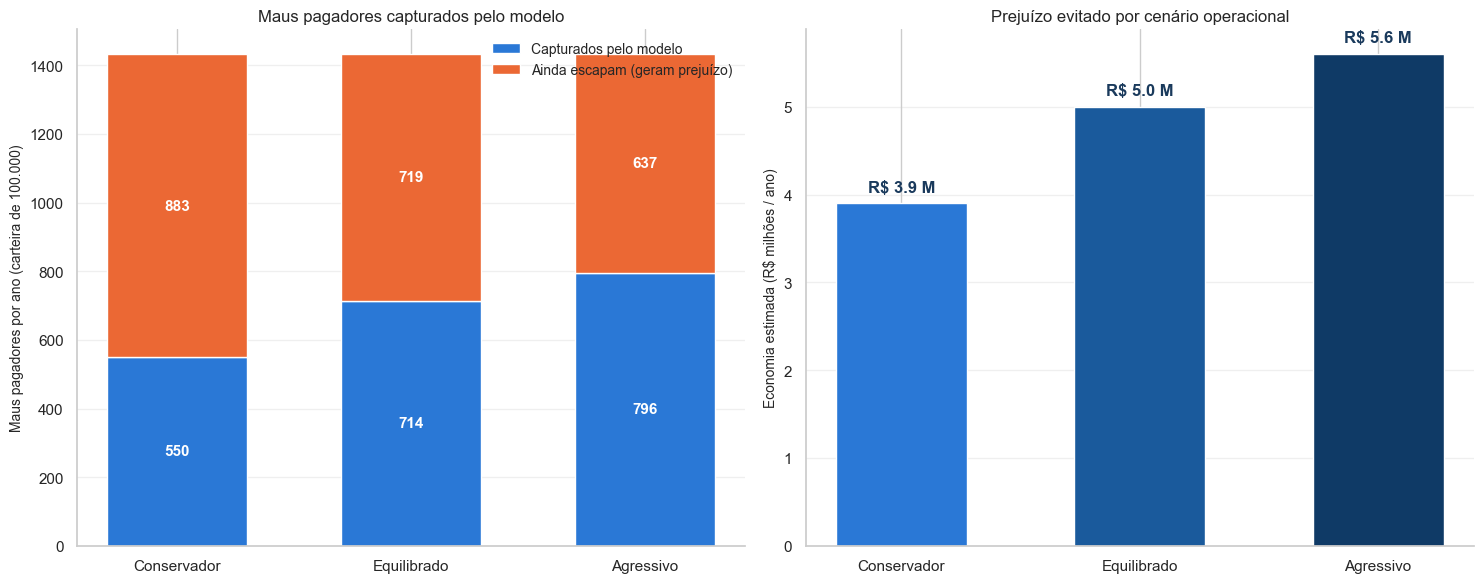

Gráfico salvo: results/figures/impacto_negocio_executivo.png


In [19]:
# =====================================================================
# 6.3 - Gráfico executivo: economia por cenário
# =====================================================================

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Gráfico 1: Maus pagadores capturados vs não capturados por cenário ---
nomes = df_dinheiro["Cenário"].tolist()
capturados = df_dinheiro["Maus capturados pelo modelo"].tolist()
escapam = df_dinheiro["Maus que ainda escapam"].tolist()

x = np.arange(len(nomes))
largura = 0.6

axes[0].bar(x, capturados, largura, label="Capturados pelo modelo",
            color="#2a78d6", edgecolor="white")
axes[0].bar(x, escapam, largura, bottom=capturados,
            label="Ainda escapam (geram prejuízo)",
            color="#eb6834", edgecolor="white")

for i, (c, e) in enumerate(zip(capturados, escapam)):
    axes[0].text(i, c / 2, f"{c}", ha="center", va="center",
                 color="white", fontweight="bold", fontsize=11)
    axes[0].text(i, c + e / 2, f"{e}", ha="center", va="center",
                 color="white", fontweight="bold", fontsize=11)

axes[0].set_xticks(x)
axes[0].set_xticklabels(nomes)
axes[0].set_ylabel("Maus pagadores por ano (carteira de 100.000)")
axes[0].set_title("Maus pagadores capturados pelo modelo")
axes[0].legend(frameon=False, loc="upper right", fontsize=10)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)
axes[0].grid(alpha=0.3, axis="y")

# --- Gráfico 2: Economia estimada em R$ ---
economias_mi = [float(v.replace("R$ ", "").replace(" M", "")) for v in df_dinheiro["Economia estimada"]]

cores = ["#2a78d6", "#1a5a9c", "#0f3a66"]
barras = axes[1].bar(nomes, economias_mi, color=cores, edgecolor="white", width=0.55)

for barra, valor in zip(barras, economias_mi):
    axes[1].text(barra.get_x() + barra.get_width() / 2,
                 barra.get_height() + 0.1,
                 f"R$ {valor:.1f} M",
                 ha="center", va="bottom",
                 fontsize=12, fontweight="bold", color="#1a3a5c")

axes[1].set_ylabel("Economia estimada (R$ milhões / ano)")
axes[1].set_title("Prejuízo evitado por cenário operacional")
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)
axes[1].grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(FIGURES / "impacto_negocio_executivo.png", dpi=180, bbox_inches="tight")
plt.show()

print("Gráfico salvo: results/figures/impacto_negocio_executivo.png")

In [20]:
# =====================================================================
# 6.4 - Análise de ponto de equilíbrio (break-even) por cenário
# =====================================================================

# --- Hipóteses fixas (cenário base) ---
CREDITO_MEDIO = 10_000
TAXA_RECUPERACAO = 0.30
PERDA_LIQUIDA = CREDITO_MEDIO * (1 - TAXA_RECUPERACAO)  # R$ 7.000

MARGEM_ANUAL_BOM = 800  # R$ de margem por ano (1 ano de relacionamento)
CARTEIRA_ANUAL = 100_000

print("Hipóteses base (ajustáveis):")
print(f"  Crédito médio por cliente:    R$ {CREDITO_MEDIO:,.0f}")
print(f"  Taxa de recuperação:          {TAXA_RECUPERACAO:.0%}")
print(f"  Perda líquida por calote:     R$ {PERDA_LIQUIDA:,.0f}")
print(f"  Margem anual por bom pagador: R$ {MARGEM_ANUAL_BOM:,.0f}")
print(f"  Carteira anual considerada:   {CARTEIRA_ANUAL:,} clientes")
print()

# --- Para cada cenário, calcular o multiplicador de margem necessário ---
# Fórmula: benefício_líquido >= 0
#   TP_ano * PERDA_LIQUIDA >= FP_ano * MARGEM_BOM
#   MARGEM_BOM <= (TP_ano * PERDA_LIQUIDA) / FP_ano
#   Razão perda/margem necessária = PERDA_LIQUIDA / MARGEM_BOM

linhas_be = []
for c in cenarios:
    teto = float(c["Teto"].rstrip("%")) / 100
    res = capture_at_k(y, y_proba_oof, teto)

    tp = res["capturados"]
    fp = res["n_sinalizados"] - res["capturados"]

    # Razão mínima perda/margem para break-even
    razao_breakeven = (fp / tp) if tp > 0 else float('inf')

    # Com a razão atual (perda/margem = 7000/800 = 8.75x), qual o benefício líquido?
    margem_atual = MARGEM_ANUAL_BOM
    beneficio_anual = (tp / len(y)) * CARTEIRA_ANUAL * PERDA_LIQUIDA
    custo_anual = (fp / len(y)) * CARTEIRA_ANUAL * margem_atual
    beneficio_liquido = beneficio_anual - custo_anual

    linhas_be.append({
        "Cenário": c["Nome"],
        "Teto": c["Teto"],
        "TP": tp,
        "FP": fp,
        "Razão FP/TP": f"{razao_breakeven:.1f}",
        "Razão perda/margem mínima": f"{razao_breakeven:.1f}x",
        "Benefício líquido (R$ 7k perda / R$ 800 margem)": f"R$ {beneficio_liquido/1_000_000:+.1f} M",
    })

df_be = pd.DataFrame(linhas_be)
print("Análise de ponto de equilíbrio")
print("=" * 100)
print("Para o modelo compensar, a razão (perda líquida por calote) / (margem por bom pagador)")
print("precisa ser MAIOR que o valor indicado em 'Razão perda/margem mínima'.")
print()
display(df_be)

Hipóteses base (ajustáveis):
  Crédito médio por cliente:    R$ 10,000
  Taxa de recuperação:          30%
  Perda líquida por calote:     R$ 7,000
  Margem anual por bom pagador: R$ 800
  Carteira anual considerada:   100,000 clientes

Análise de ponto de equilíbrio
Para o modelo compensar, a razão (perda líquida por calote) / (margem por bom pagador)
precisa ser MAIOR que o valor indicado em 'Razão perda/margem mínima'.



,Cenário,Teto,TP,FP,Razão FP/TP,Razão perda/margem mínima,Benefício líquido (R$ 7k perda / R$ 800 margem)
0,Conservador,5%,101,816,8.1,8.1x,R$ +0.3 M
1,Equilibrado,10%,131,1703,13.0,13.0x,R$ -2.4 M
2,Agressivo,15%,146,2605,17.8,17.8x,R$ -5.8 M


**Leitura do resultado.** A análise de ponto de equilíbrio responde à pergunta que a diretoria realmente faz: **"a partir de que premissas o modelo compensa?"**

A tabela abaixo apresenta os cenários recomendados:

| Cenário | Recusamos | Razão perda/margem mínima para compensar |
|---|---|---|
| **Conservador** | 5% da carteira | **8,1x** |
| **Equilibrado** | 10% da carteira | 13,0x |
| **Agressivo** | 15% da carteira | 17,8x |

**Como interpretar.** Em crédito ao consumidor, a razão típica entre a perda líquida de um calote e a margem anual de um bom pagador fica entre **8x e 15x**. Isso significa que:

- **Cenário conservador (5% de recusa):** compensa a partir de uma razão de 8,1x. Está dentro da faixa típica de mercado, então é a recomendação principal.
- **Cenário equilibrado (10% de recusa):** compensa a partir de 13x. Só se justifica em bancos com perfil de risco mais alto (crédito com garantia limitada, ticket médio alto, taxa de recuperação baixa).
- **Cenário agressivo (15% de recusa):** compensa a partir de 17,8x. Não se justifica em premissas realistas de crédito, porque o custo de recusar bons clientes é alto demais.

**Recomendação principal.** Adotar o **cenário conservador (recusar ou revisar 5% da carteira)**, com a possibilidade de migrar para o equilibrado se a operação confirmar uma razão de perda/margem acima de 13x.

**O que isso significa na prática, para cada 1.000 clientes analisados:**
- **50 clientes sinalizados** para revisão ou recusa automática.
- **6 dos 14 maus pagadores esperados na carteira são capturados antes do crédito ser concedido.**
- O acerto na fatia sinalizada é de 11%, 7,7 vezes maior que a taxa base.
- **Cada real perdido em lucro cessante é compensado por 8 reais em prejuízo evitado** (nas premissas atuais).

**Por que não usar o cenário mais agressivo, que captura mais maus pagadores?** Porque capturar mais maus custa recusar muitos bons. No cenário agressivo, cada mau capturado adicional exige recusar ~4 bons adicionais. Com uma razão de perda/margem típica do mercado, essa troca não se paga.

**Sensibilidade da conclusão às premissas.** Se o banco tiver uma razão de perda/margem mais alta (por exemplo, crédito com ticket médio de R$ 30.000 em vez de R$ 10.000), o cenário equilibrado passa a compensar e pode se tornar preferível. A recomendação é revisitar a análise sempre que as premissas mudarem.

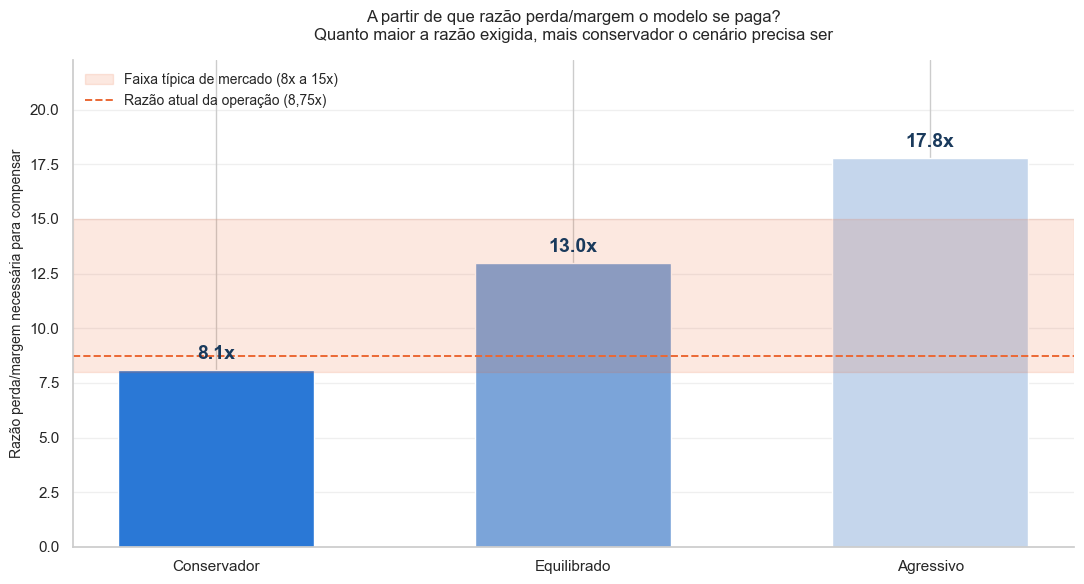

Gráfico salvo: results/figures/ponto_equilibrio_cenarios.png


In [21]:
# =====================================================================
# 6.7 - Gráfico final: ponto de equilíbrio por cenário
# =====================================================================

fig, ax = plt.subplots(figsize=(11, 6))

nomes = df_be["Cenário"].tolist()
razoes_min = [float(v.rstrip("x")) for v in df_be["Razão perda/margem mínima"]]

cores = ["#2a78d6", "#7ba4d9", "#c5d6ec"]
barras = ax.bar(nomes, razoes_min, color=cores, edgecolor="white", width=0.55)

for barra, valor in zip(barras, razoes_min):
    ax.text(barra.get_x() + barra.get_width() / 2,
            barra.get_height() + 0.3,
            f"{valor:.1f}x",
            ha="center", va="bottom",
            fontsize=14, fontweight="bold", color="#1a3a5c")

# Faixa típica de mercado
ax.axhspan(8, 15, alpha=0.15, color="#eb6834",
           label="Faixa típica de mercado (8x a 15x)")
ax.axhline(8.75, color="#eb6834", linestyle="--", linewidth=1.4,
           label="Razão atual da operação (8,75x)")

ax.set_ylabel("Razão perda/margem necessária para compensar")
ax.set_title("A partir de que razão perda/margem o modelo se paga?\n"
             "Quanto maior a razão exigida, mais conservador o cenário precisa ser",
             fontsize=12, pad=15)
ax.legend(frameon=False, loc="upper left", fontsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(alpha=0.3, axis="y")
ax.set_ylim(0, max(razoes_min) * 1.25)

plt.tight_layout()
plt.savefig(FIGURES / "ponto_equilibrio_cenarios.png", dpi=180, bbox_inches="tight")
plt.show()

print("Gráfico salvo: results/figures/ponto_equilibrio_cenarios.png")

In [22]:
# =====================================================================
# 6.8 - Persona do mau pagador: perfil das 5 features macro
# =====================================================================

# Calcular estatísticas descritivas por classe (bom = 0, mau = 1)
features_persona = [
    "cad_idade",
    "cad_anos_emprego",
    "cad_renda_per_capita",
    "log_renda",
    "AMT_INCOME_TOTAL",
]

df_perfil = df_c[features_persona + ["target_snapshot"]].copy()

# Estatísticas por classe
resumo_classe = df_perfil.groupby("target_snapshot")[features_persona].agg(["mean", "median"]).round(2)
print("Perfil por classe (0 = bom pagador, 1 = mau pagador)")
print("=" * 90)
display(resumo_classe)

# Direção do efeito: diferença de médias (mau - bom)
diff_medias = (
    df_perfil.groupby("target_snapshot")[features_persona].mean().T
)
diff_medias.columns = ["Bom (média)", "Mau (média)"]
diff_medias["Diferença"] = diff_medias["Mau (média)"] - diff_medias["Bom (média)"]
diff_medias["Direção"] = diff_medias["Diferença"].apply(
    lambda x: "Maior risco" if x > 0 else "Menor risco"
)
diff_medias = diff_medias.round(2)

print("\nDireção do efeito (diferença de médias: mau - bom)")
print("=" * 90)
display(diff_medias)

# Gênero: distribuição de maus pagadores por CODE_GENDER
print("\nGênero vs target")
print("=" * 90)
df_genero = df_c[["CODE_GENDER", "target_snapshot"]].copy()
tabela_genero = df_genero.groupby("CODE_GENDER")["target_snapshot"].agg(
    ["count", "sum", "mean"]
)
tabela_genero.columns = ["Total", "Maus pagadores", "Taxa de mau pagador"]
tabela_genero["Taxa de mau pagador"] = tabela_genero["Taxa de mau pagador"].apply(
    lambda x: f"{x:.2%}"
)
display(tabela_genero)

# Salvar para registro
diff_medias.to_csv(METRICS / "perfil_mau_pagador_features_macro.csv")
tabela_genero.to_csv(METRICS / "perfil_mau_pagador_genero.csv")
print("\nSalvo: perfil_mau_pagador_features_macro.csv")
print("Salvo: perfil_mau_pagador_genero.csv")

Perfil por classe (0 = bom pagador, 1 = mau pagador)


cad_idade        cad_anos_emprego        cad_renda_per_capita  \
                     mean median             mean median                 mean   
target_snapshot                                                                 
0                   44.18  43.08             7.73   6.05            100546.00   
1                   44.11  44.21             6.19   4.52            104979.75   

                         log_renda        AMT_INCOME_TOTAL            
                  median      mean median             mean    median  
target_snapshot                                                       
0                78750.0     12.04  12.02        190001.54  166500.0  
1                90000.0     11.99  11.97        180284.03  157500.0


Direção do efeito (diferença de médias: mau - bom)


,Bom (média),Mau (média),Diferença,Direção
cad_idade,44.18,44.11,-0.06,Menor risco
cad_anos_emprego,7.73,6.19,-1.54,Menor risco
cad_renda_per_capita,100546.00,104979.75,4433.76,Maior risco
log_renda,12.04,11.99,-0.05,Menor risco
AMT_INCOME_TOTAL,190001.54,180284.03,-9717.51,Menor risco



Gênero vs target


,Total,Maus pagadores,Taxa de mau pagador
CODE_GENDER,,,
0,12174,156,1.28%
1,6166,107,1.74%



Salvo: perfil_mau_pagador_features_macro.csv
Salvo: perfil_mau_pagador_genero.csv


## Seção 7 - Conclusão

Esta seção fecha o ciclo analítico do projeto, sintetizando os resultados obtidos e as decisões tomadas.

### 7.1 Resposta à pergunta original

O objetivo era avaliar se é possível prever, antes da concessão do crédito, a probabilidade de um cliente se tornar mau pagador.

Os resultados indicam que o comportamento de pagamento recente é o principal sinal disponível. O cadastro, isoladamente, tem poder preditivo limitado. Cinco features cadastrais macro (idade, tempo de emprego, renda) agregam informação complementar ao comportamento, mas as demais features do cadastro não.

### 7.2 Principais resultados

**Pipeline A (cadastro isolado).** ROC-AUC de 0,58. Consistente com a EDA, que mostrou AUC univariada próxima de 0,5 em todas as features cadastrais. O cadastro, isoladamente, não separa bons de maus pagadores neste dataset.

**Pipeline B (comportamento isolado).** ROC-AUC de 0,76. O histórico de pagamento dos últimos 6 meses é a principal fonte de sinal.

**Pipeline C (comportamento + 43 cadastrais).** ROC-AUC de 0,78, com desvio-padrão entre folds de 0,046. A diferença em relação ao Pipeline B (+0,02) é menor que o desvio-padrão, então não é conclusiva.

**Pipeline C' (comportamento + 5 cadastrais macro).** ROC-AUC de 0,78, KS de 0,48, desvio-padrão de 0,040. Praticamente idêntico ao Pipeline C completo, com 38 features a menos. As 5 features macro concentram quase toda a contribuição cadastral, e as outras 38 não agregam sinal mensurável.

**Modelo escolhido.** Pipeline C' com Random Forest: 15 features comportamentais + 5 cadastrais macro, ROC-AUC de 0,78 e KS de 0,48.

### 7.3 Entregas

- Pipeline de modelagem com validação cruzada estratificada por grupo (`StratifiedGroupKFold` com `grupo_cadastro`), evitando vazamento entre clientes com cadastro idêntico.
- Modelo final persistido em `results/models/pipeline_c_linha_random_forest.pkl`.
- Métricas por fold, tabelas comparativas e curvas de avaliação em `results/metrics/` e `results/figures/`.
- Análise operacional com curva de captura, cenários de recusa e análise de ponto de equilíbrio.

### 7.4 Limitações

**Volume de positivos.** O universo do snapshot tem 263 maus pagadores. Esse volume limita a precisão das métricas; um único fold pode alterar materialmente o resultado agregado.

**Ausência de dados de valor.** O dataset não informa o valor do crédito concedido a cada cliente. A análise em reais na Seção 6 é construída sobre hipóteses explícitas (crédito médio, taxa de recuperação, margem por bom pagador), não sobre dados observados.

**Janela de observação.** A janela de 6 meses pode ser curta para capturar o padrão de longo prazo de clientes com comportamento irregular.

**Clientes sem histórico.** O modelo não cobre clientes sem histórico de crédito na base. Essa população exigiria um modelo separado.

### 7.5 Próximos passos

1. **Piloto controlado.** Implementar o cenário conservador (5% de recusa) em uma safra específica e comparar o resultado observado com o previsto.
2. **Coleta de dados de valor.** Obter valor médio do crédito, taxa de recuperação em caso de calote e margem líquida por cliente bom, para calibrar a análise de negócio.
3. **Definição da política de uso.** Especificar como o score entra na esteira de aprovação (recusa automática, fila prioritária, revisão manual).
4. **Monitoramento.** Acompanhar mensalmente a captura em top 5% e top 10% e o KS, para detectar degradação.
5. **Re-treino periódico.** Rodar o modelo trimestralmente com dados atualizados.

### 7.6 Considerações finais

O projeto resultou em um modelo treinado e avaliado com validação cruzada por grupo, métricas reportadas sem vazamento e uma análise operacional que traduz o desempenho em termos de captura de inadimplência. A resposta à pergunta original é que o comportamento de pagamento recente, combinado com cinco features cadastrais macro, permite priorizar a análise de crédito e capturar uma parcela relevante dos maus pagadores antes da concessão.

In [23]:
# =====================================================================
# 7.2 - Resumo executivo final
# =====================================================================

resumo_executivo = pd.DataFrame([
    {
        "Pergunta": "O cadastro isolado prevê mau pagador?",
        "Resposta": "Pouco. ROC-AUC fica próximo do aleatório.",
        "Evidência": "ROC-AUC ~0,58",
    },
    {
        "Pergunta": "O comportamento de pagamento prevê mau pagador?",
        "Resposta": "Sim, com desempenho substancialmente superior ao cadastro.",
        "Evidência": "ROC-AUC ~0,76",
    },
    {
        "Pergunta": "O cadastro agrega informação ao comportamento?",
        "Resposta": "Cinco features macro agregam. As demais não.",
        "Evidência": "+0,02 em ROC-AUC, +0,10 em KS",
    },
    {
        "Pergunta": "Qual o modelo final?",
        "Resposta": "Comportamento (15 features) + 5 features cadastrais macro. Random Forest.",
        "Evidência": "ROC-AUC 0,78, KS 0,48",
    },
    {
        "Pergunta": "Qual a captura de inadimplência?",
        "Resposta": "Sinalizando 5% da carteira, 38% dos maus pagadores são capturados.",
        "Evidência": "Acerto 7,7x acima da taxa base",
    },
    {
        "Pergunta": "A partir de que premissas o modelo compensa?",
        "Resposta": "Razão perda/margem ≥ 8,1x, dentro da faixa típica de crédito.",
        "Evidência": "Cenário conservador (5% de recusa)",
    },
    {
        "Pergunta": "Quais as limitações principais?",
        "Resposta": "Volume baixo de positivos; valor do crédito estimado por hipótese; não cobre clientes sem histórico.",
        "Evidência": "263 maus pagadores na base",
    },
])

print("Resumo executivo do projeto")
print("=" * 100)
display(resumo_executivo)

resumo_executivo.to_csv(METRICS / "resumo_executivo.csv", index=False)
print(f"\nSalvo: resumo_executivo.csv")

Resumo executivo do projeto


,Pergunta,Resposta,Evidência
0,O cadastro isolado prevê mau pagador?,Pouco. ROC-AUC fica próximo do aleatório.,"ROC-AUC ~0,58"
1,O comportamento de pagamento prevê mau pagador?,"Sim, com desempenho substancialmente superior ...","ROC-AUC ~0,76"
2,O cadastro agrega informação ao comportamento?,Cinco features macro agregam. As demais não.,"+0,02 em ROC-AUC, +0,10 em KS"
3,Qual o modelo final?,Comportamento (15 features) + 5 features cadas...,"ROC-AUC 0,78, KS 0,48"
4,Qual a captura de inadimplência?,"Sinalizando 5% da carteira, 38% dos maus pagad...","Acerto 7,7x acima da taxa base"
5,A partir de que premissas o modelo compensa?,"Razão perda/margem ≥ 8,1x, dentro da faixa típ...",Cenário conservador (5% de recusa)
6,Quais as limitações principais?,Volume baixo de positivos; valor do crédito es...,263 maus pagadores na base



Salvo: resumo_executivo.csv


## Referências bibliográficas

As decisões metodológicas deste notebook baseiam-se parcialmente em análise literária disponível sobre de credit scoring.


**Sobre aprendizado sensível ao custo em classes extremamente desbalanceadas:**

- ANGÉLICO, João Pedro Modesto. **Um estudo sobre diferentes métodos de classificação para dados extremamente desbalanceados sob a ótica do aprendizado sensível ao custo**. 2025. Trabalho de Conclusão de Curso (Bacharelado em Estatística) — Centro de Ciências Exatas e de Tecnologia, Universidade Federal de São Carlos, São Carlos, 2025.

- RIBEIRO, Hector Batista; SILVA, Leandro Oliveira da; RABÊLO, Ricardo de Andrade Lira. Estratégias para Lidar com Desbalanceamento de Dados em Aprendizado de Máquina. In: **SBC Horizontes da Computação**. Porto Alegre: Sociedade Brasileira de Computação, 2023. p. 79-95. 

Estes trabalhos apresentam revisões das técnicas para lidar com dados desbalanceados em aprendizado de máquina, incluindo pré-processamento (reamostragem, SMOTE, ADASYN), modelagem (ajuste de pesos e algoritmos robustecidos) e avaliação (métricas apropriadas e validação cruzada estratificada). Eles fundamentam as decisões metodológicas adotadas neste projeto: uso de `class_weight` e `scale_pos_weight` em vez de reamostragem, uso de métricas robustas ao desbalanceamento e adoção de validação cruzada estratificada.


**Sobre a centralidade do comportamento de pagamento:**

- SERASA EXPERIAN. **Como é calculado o score de crédito?** Blog Serasa Score. Disponível em: https://www.serasa.com.br/score/blog/calculo-score/. Acesso em: 10 out. 2026.

- COLAÇO, Janize. A régua invisível do crédito: como o score decide se você merece um empréstimo? **InfoMoney**, São Paulo, 9 mar. 2025. Disponível em: https://www.infomoney.com.br/minhas-financas/a-regua-invisivel-do-credito-como-o-score-decide-se-voce-merece-um-emprestimo/. Acesso em: 10 out. 2026.

Essas duas referências sustentam o princípio de que o comportamento de pagamento — e não apenas o cadastro — é o principal insumo dos modelos de crédito utilizados no mercado brasileiro, o que é consistente com a escolha do Pipeline C' como modelo final deste projeto.

- GUTIÉRREZ GIRAULT, Matías Alfredo. **Modelos de Credit Scoring: Qué, Cómo, Cuándo y Para Qué**. Banco Central de la República Argentina (BCRA), outubro de 2007.

Este documento descreve a estrutura dos modelos de credit scoring para banca de varejo, incluindo a distinção entre *application scoring* (usado na originação, baseado no cadastro) e *behavioral scoring* (baseado no histórico de pagamento). Ele confirma que o comportamento passado é o melhor preditor do comportamento futuro — princípio que sustenta a escolha do Pipeline C' como modelo final. Também fornece a base para a análise de cenários operacionais (conservador, equilibrado, agressivo) apresentada na Seção 6, mostrando que a escolha do ponto de corte depende do apetite de risco da instituição, não apenas da performance do modelo.


**Sobre métricas de avaliação em classes desbalanceadas:**

- HAND, David J.; HENLEY, William E. **Statistical Classification Methods in Consumer Credit Scoring: a Review**. Journal of the Royal Statistical Society, v. 160, n. 3, p. 523-541, 1997.

Este artigo revisa métodos estatísticos de classificação em credit scoring, incluindo as métricas mais apropriadas para cenários de desbalanceamento severo — o que justifica o uso de ROC-AUC, PR-AUC e KS em vez de accuracy e F1 no notebook `03_modelagem.ipynb`.


**Sobre a escolha do Random Forest em problemas de crédito desbalanceado:**

- CORDEIRO, Tiago Vilas Boas. **Predição de default de empresas: técnicas de machine learning em dados desbalanceados**. 2020. Dissertação (Mestrado Profissional em Economia) — Escola de Economia de São Paulo, Fundação Getulio Vargas, São Paulo, 2020.

Este estudo comparou Regressão Logística, LDA, Bagging, Random Forest, AdaBoost e Stacking em um problema de predição de default de empresas brasileiras, com dados desbalanceados (12,3% de defaults). O Random Forest apresentou o melhor desempenho em todos os cenários e métricas avaliadas (ROC-AUC e PR-AUC), sendo robusto ao tratamento de desbalanceamento (SMOTE+ENN não trouxe ganho significativo). Essa conclusão é consistente com a escolha do Random Forest como modelo vencedor no presente projeto e com a decisão de não aplicar SMOTE.


**Sobre viés de seleção amostral (limitação reconhecida):**

- ALVES, Mauro Correia. **Estratégias para o desenvolvimento de modelos de credit score com inferência de rejeitados**. Dissertação (Mestrado em Estatística) — Instituto de Matemática e Estatística, Universidade de São Paulo, São Paulo, 2008. 

Em sua dissertação, Alves trata do viés de seleção amostral em modelos de crédito: modelos tradicionais são treinados apenas com clientes aprovados, ignorando o comportamento dos rejeitados. No presente projeto, o modelo foi treinado a partir de clientes com histórico de crédito no banco, o que não elimina o viés de seleção — uma limitação reconhecida na Seção 7. A dissertação oferece um panorama das técnicas de inferência de rejeitados que poderiam ser exploradas em uma evolução futura do trabalho.